# TableRAG — recorded and live walkthrough
### _single file · replays a recorded run, then executes the loop for real_

TableRAG answers questions over documents that mix prose with tables.

Ordinary RAG flattens a table into text and retrieves fragments of it, so a question needing a
count, a maximum or a percentage is computed over the handful of rows that happened to be
retrieved rather than over the whole table. TableRAG loads tables into a SQL database instead,
keeps prose in a vector store, and runs a short loop that queries whichever it needs.

> Xiaohan Yu, Pu Jian, Chong Chen. *TableRAG: A Retrieval Augmented Generation Framework for
> Heterogeneous Document Reasoning.* EMNLP 2025, pp. 14063–14082.

## How it works

**Offline, once.** Two stores are built from the same documents:

| Store | Holds | Used for |
|---|---|---|
| SQLite database | one table per source table, typed columns | exact computation |
| Chunk corpus | prose, plus Markdown renderings of the tables | semantic retrieval |

Every table-derived chunk records **which table it came from**. That back-pointer is the mapping
`f`, and it is what turns a retrieval hit into a SQL schema. No model runs offline — the schema is
built by deterministic code from the header row and the cell values.

**Online, per question.** At most 5 iterations of four steps:

| Step | What happens |
|---|---|
| ① decompose | the model reads the table and emits one sub-question — or stops and answers |
| ② retrieve | 30 chunks by embedding, reranked to the top 3 |
| ③ SQL | if a table chunk was retrieved, write SQL and execute it, repairing once on failure. **Skipped entirely if no table chunk came back** |
| ④ combine | cross-examine the retrieved text against the SQL result; fall back to text if SQL is empty |

## What this notebook does

Shows the same question twice. First replayed from a recorded run, stage by stage, so every prompt
and every intermediate object is visible. Then executed **live** against the API, so you can watch
the loop make its own decisions — and compare the two paths.

| Section | | Needs a key |
|---|---|---|
| 1 | The data — embedded below, nothing to download | no |
| 2 | The two offline stores, built from that data | no |
| 3 | The four steps replayed, with the real prompts | no |
| 4 | Run totals, the baseline, and an editable SQL cell | no |
| 5 | The same loop executed live | **yes** |
| 6 | Your own question, and a live NaiveRAG comparison | **yes** |

Sections 1–4 need nothing. Sections 5–6 cost about **\$0.01–\$0.05 per question** on
`claude-haiku-4-5` and are skipped automatically if no key is present.

**Key:** Colab → key icon in the sidebar → name it `ANTHROPIC_API_KEY`. Kaggle → *Add-ons →
Secrets*. Never paste a key into a cell.

## The traced question

> *What city hosted the World Championship in the season that Shouta Yasooka ranked 5th twice?*
> — gold answer **Chiba**

It needs both stores: the season is only derivable from the table, the host city appears only in
the prose. NaiveRAG — same retriever, same model, one call — answers **New York**.

For context, measured over the full runs: HybridQA **+19.67** points for TableRAG
(*p* = 2.6 × 10⁻⁹, n = 305); ViNumQA-50 **−4.00** (*p* = 0.73, n = 50).

---
## 1. The data

The entire recorded run for this question — source table, schema, all six chunks with full text,
the execution trace and the prompt templates. Readable JSON, about 33 KB, so it can be checked
against what the notebook does with it.

In [1]:
import os, sys, re, json, sqlite3, textwrap
from pathlib import Path

PROMPTS = json.loads(r"""
{
 "SYSTEM_EXPLORE_PROMPT": "Next, you will complete a table-related question answering task. Based on the provided materials such as the table content (in Markdown format), you need to analyze the User Query.\nAnd try to decide whether the User Input Query should be broken down into subqueries. You are provided with \"solve_subquery\" tool that can get answer for the subqueries.\nAfter you have collected sufficient information, you need to generate comprehensive answers.\n\nTable Contet: {table_content}\n\nInstructions:\n1. Carefully analyze each user query through step-by-step reasoning.\n2. If the query needs information more than the given table content：\n    - Decompose the query into subqueries.\n    - Process one subquery at a time.\n    - Use \"solve_subquery\" tool to get answers for each subquey.\n3. If a query can be answered by table content, do not decompose it. And directly put the orignal query into the \"solve_subquery\" tool.\n    The \"solve_subquery\" tool utilizes SQL execution inside, it can solve complex subquery on table through one tool call.\n4. Generate exactly ONE subquery at a time.\n5. Write out all terms completely - avoid using abbreviations.\n6. When you have sufficient information, provide the final answer in the following format:\n    <Answer>: [your complete response]\n\nUser Input Query: {query}\nPlease start!\n",
 "NL2SQL_SYSTEM_PROMPT": "You are an expert in SQL and can generate SQL statements based on table schemas and query requirements. Respond as concisely as possible, providing only the SQL statement without any additional explanations.",
 "NL2SQL_USER_PROMPT": "{schema_list}\n\nBased on the schemas above, please use {dialect} syntax to solve the following problem:\n{user_query}\n\nRules:\n1. Use ONLY the exact table and column names listed in the schema (the \"{ascii_hint}\" field).\n2. Wrap table and column names in backticks, e.g. ```sql SELECT `name` FROM `t_student_1` WHERE `age` > 15; ```\n3. When matching text values, prefer LIKE with wildcards over strict equality, since cells may contain extra whitespace or annotations.\n4. If the question requires an aggregate (count, sum, average, max, min, ranking), compute it in SQL rather than listing every row.\n5. Wrap the generated SQL statement in a ```sql ``` block.\n",
 "COMBINE_PROMPT": "You are about to complete a table-based question answernig task using the following two types of reference materials:\n\n# Content 1: Original content (table content is provided in Markdown format):\n{docs}\n\n$ Content 2: NL2SQL related Question information and SQL execution result in the database:\n# the user given table schema\n{schema}\n\n# SQL generated based on the schema and the user question:\n{nl2sql_model_response}\n\n# SQL execution results\n{sql_execute_result}\n\nPlease answer the user's question based on the materials above.\nUser question: {query}\n\nNote:\n1. The markdown table content in Content 1 may be incomplete.\n2. You should cross-validate the given two materials:\n    - if the answers are the same, directly output the answer.\n    - if the \"SQL execution result\" contains error or is empty, you should try to answer based on the Content 1.\n    - if the two materials shows conflit, you should think about each of them, and finally give an answer.\n",
 "NAIVE_RAG_PROMPT": "Answer the question using the retrieved passages below. Tables are given in Markdown format.\n\n# Retrieved passages\n{docs}\n\n# Question\n{query}\n\nAnswer directly and concisely. Give only the final answer, with no explanation. If the passages are insufficient, give the best answer you can from what is available.",
 "EVALUATION_PROMPT": "We would like to request your feedback on the performance of the AI assistant in response to the user question displayed above according to the gold answer. Please use the following listed aspects and their descriptions as evaluation criteria:\n    - Accuracy and Hallucinations: The assistant's answer is semantically consistent with the gold answer; The numerical value and order need to be accurate, and there should be no hallucinations.\n    - Completeness: Referring to the reference answers, the assistant's answer should contain all the key points needed to answer the user's question; further elaboration on these key points can be omitted.\nPlease rate whether this answer is suitable for the question. Please note that the gold answer can be considered as a correct answer to the question.\n\nThe assistant receives an overall score on a scale of 0 OR 1, where 0 means wrong and 1 means correct.\nDirctly output a line indicating the score of the Assistant.\n\nPLEASE OUTPUT WITH THE FOLLOWING FORMAT, WHERE THE SCORE IS 0 OR 1 BY STRICTLY FOLLOWING THIS FORMAT: \"[[score]]\", FOR EXAMPLE \"Rating: [[1]]\":\n<start output>\nRating: [[score]]\n<end output>\n\n[Question]\n{question}\n\n[Gold Answer]\n{golden}\n\n[The Start of Assistant's Predicted Answer]\n{gen}\n",
 "SOLVE_SUBQUERY_TOOL": {
  "name": "solve_subquery",
  "description": "Return the answer for a decomposed subquery. This tool executes SQL against a relational database and searches a text corpus, so it can resolve both computations over an entire table and facts that appear only in the linked documents.",
  "input_schema": {
   "type": "object",
   "properties": {
    "subquery": {
     "type": "string",
     "description": "The subquery to be solved, in natural language, self-contained and written out in full without abbreviations."
    }
   },
   "required": [
    "subquery"
   ],
   "additionalProperties": false
  }
 }
}
""")

EX = json.loads(r"""
{
 "why_this_example": "two SQL hops, the second returning empty and falling back to text",
 "question": "What city hosted the World Championship in the season that Shouta Yasooka ranked 5th twice ?",
 "gold": "Chiba",
 "table_id": "Shouta_Yasooka_0",
 "article_title": "Shouta_Yasooka_0",
 "table": {
  "header": [
   "Season",
   "Event type",
   "Location",
   "Format",
   "Date",
   "Rank"
  ],
  "rows": [
   [
    "2006",
    "Grand Prix",
    "Hamamatsu",
    "Team Constructed",
    "8-9 April 2006",
    "2"
   ],
   [
    "2006",
    "Grand Prix",
    "Kuala Lumpur",
    "Sealed and Booster Draft",
    "3-4 June 2006",
    "6"
   ],
   [
    "2006",
    "Pro Tour",
    "Charleston , South Carolina",
    "Team Constructed",
    "16-18 June 2006",
    "1"
   ],
   [
    "2006",
    "Grand Prix",
    "Toulouse",
    "Sealed and Booster Draft",
    "24-25 June 2006",
    "7"
   ],
   [
    "2006",
    "Grand Prix",
    "Sydney",
    "Sealed and Booster Draft",
    "7-8 October 2006",
    "7"
   ],
   [
    "2006",
    "Grand Prix",
    "New Jersey",
    "Sealed and Booster Draft",
    "11-12 November 2006",
    "8"
   ],
   [
    "2007",
    "Grand Prix",
    "Strasbourg",
    "Block Constructed",
    "19-20 May 2007",
    "3"
   ],
   [
    "2007",
    "Grand Prix",
    "Montreal",
    "Block Constructed",
    "23-24 June 2007",
    "8"
   ],
   [
    "2007",
    "Invitational",
    "Essen",
    "Special",
    "18-21 October 2007",
    "8"
   ],
   [
    "2007",
    "Grand Prix",
    "Kitakyushu",
    "Sealed and Booster Draft",
    "10-11 November 2007",
    "2"
   ],
   [
    "2008",
    "Grand Prix",
    "Manila",
    "Block Constructed",
    "30-31 August 2008",
    "2"
   ],
   [
    "2010",
    "Grand Prix",
    "Kuala Lumpur",
    "Standard",
    "13-14 March 2010",
    "5"
   ],
   [
    "2010",
    "Grand Prix",
    "Sendai",
    "Standard",
    "5-6 June 2010",
    "3"
   ],
   [
    "2010",
    "Nationals",
    "Kyoto",
    "Standard and Booster Draft",
    "2-4 July 2010",
    "5"
   ],
   [
    "2011",
    "Grand Prix",
    "Kobe",
    "Extended",
    "23-24 April 2011",
    "1"
   ],
   [
    "2011",
    "Grand Prix",
    "Singapore",
    "Standard",
    "4-5 June 2011",
    "5"
   ],
   [
    "2011",
    "Nationals",
    "Osaka",
    "Special",
    "15-17 July 2011",
    "6"
   ],
   [
    "2011",
    "Grand Prix",
    "Brisbane",
    "Standard",
    "15-16 October 2011",
    "8"
   ],
   [
    "2012-13",
    "Grand Prix",
    "Boston-Worcester",
    "Sealed and Booster Draft",
    "25-26 August 2012",
    "8"
   ],
   [
    "2012-13",
    "Players Championship",
    "Indianapolis",
    "Special",
    "29-31 August 2012",
    "2"
   ]
  ]
 },
 "schema": {
  "table_id": "Shouta_Yasooka_0",
  "sql_table_name": "t_shouta_yasooka_0",
  "article_title": "Shouta_Yasooka_0",
  "columns": [
   {
    "original_name": "Season",
    "sql_name": "season",
    "dtype": "INTEGER",
    "examples": [
     "2006",
     "2006",
     "2006"
    ]
   },
   {
    "original_name": "Event type",
    "sql_name": "event_type",
    "dtype": "TEXT",
    "examples": [
     "Grand Prix",
     "Grand Prix",
     "Pro Tour"
    ]
   },
   {
    "original_name": "Location",
    "sql_name": "location",
    "dtype": "TEXT",
    "examples": [
     "Hamamatsu",
     "Kuala Lumpur",
     "Charleston , South Carolina"
    ]
   },
   {
    "original_name": "Format",
    "sql_name": "format",
    "dtype": "TEXT",
    "examples": [
     "Team Constructed",
     "Sealed and Booster Draft",
     "Team Constructed"
    ]
   },
   {
    "original_name": "Date",
    "sql_name": "date",
    "dtype": "TEXT",
    "examples": [
     "8-9 April 2006",
     "3-4 June 2006",
     "16-18 June 2006"
    ]
   },
   {
    "original_name": "Rank",
    "sql_name": "rank",
    "dtype": "INTEGER",
    "examples": [
     "2",
     "6",
     "1"
    ]
   }
  ],
  "n_rows": 20
 },
 "chunks": [
  {
   "chunk_id": "Shouta_Yasooka_0::table::0",
   "source": "table",
   "table_id": "Shouta_Yasooka_0",
   "text": "Bảng từ bài viết: Shouta_Yasooka_0\n| Season | Event type | Location | Format | Date | Rank |\n| --- | --- | --- | --- | --- | --- |\n| 2006 | Grand Prix | Hamamatsu | Team Constructed | 8-9 April 2006 | 2 |\n| 2006 | Grand Prix | Kuala Lumpur | Sealed and Booster Draft | 3-4 June 2006 | 6 |\n| 2006 | Pro Tour | Charleston , South Carolina | Team Constructed | 16-18 June 2006 | 1 |\n| 2006 | Grand Prix | Toulouse | Sealed and Booster Draft | 24-25 June 2006 | 7 |\n| 2006 | Grand Prix | Sydney | Sealed and Booster Draft | 7-8 October 2006 | 7 |\n| 2006 | Grand Prix | New Jersey | Sealed and Booster Draft | 11-12 November 2006 | 8 |\n| 2007 | Grand Prix | Strasbourg | Block Constructed | 19-20 May 2007 | 3 |\n| 2007 | Grand Prix | Montreal | Block Constructed | 23-24 June 2007 | 8 |\n| 2007 | Invitational | Essen | Special | 18-21 October 2007 | 8 |\n| 2007 | Grand Prix | Kitakyushu | Sealed and Booster Draft | 10-11 November 2007 | 2 |\n| 2008 | Grand Prix | Manila | Block Constructed | 30-31 August 2008 | 2 |\n| 2010 | Grand Prix | Kuala Lumpur | Standard | 13-14 March 2010 | 5 |\n| 2010 | Grand Prix | Sendai | Standard | 5-6 June 2010 | 3 |\n| 2010 | Nationals | Kyoto | Standard and Booster Draft | 2-4 July 2010 | 5 |\n| 2011 | Grand Prix | Kobe | Extended | 23-24 April 2011 | 1 |\n| 2011 | Grand Prix | Singapore | Standard | 4-5 June 2011 | 5 |\n| 2011 | Nationals | Osaka | Special | 15-17 July 2011 | 6 |\n| 2011 | Grand Prix | Brisbane | Standard | 15-16 October 2011 | 8 |\n| 2012-13 | Grand Prix | Boston-Worcester | Sealed and Booster Draft | 25-26 August 2012 | 8 |\n| 2012-13 | Players Championship | Indianapolis | Special | 29-31 August 2012 | 2 |"
  },
  {
   "chunk_id": "Shouta_Yasooka_0::text::0",
   "source": "text",
   "table_id": null,
   "text": "Bài viết: Shouta_Yasooka_0\n[Magic: The Gathering formats] Magic : The Gathering formats are various ways in which the Magic : The Gathering collectible card game can be played . Each format provides rules for deck construction and gameplay , with many confining the pool of permitted cards to those released in a specified group of Magic card sets . The DCI , the governing body that oversees official Magic competitive play , categorizes its tournament formats into Constructed and Limited . Constructed formats require decks to be made prior to participation , with players allowed to use any tournament-legal cards they possess . Sanctioned Constructed formats include Standard , Modern , Legacy , and Vintage . Limited formats , in contrast , utilize a restricted and unknown pool of cards , usually formed by opening Magic products . Limited competition require players to select cards and build decks on the fly within the tournament itself . The primary two sanctioned Limited formats are Sealed Deck and Booster Draft . A number of other formats have been designed by Wizards of the Coast or by players for custom gameplay or reduced investment cost ; these are known as casual formats . Some casual formats utilize rules or sets of cards that differ from those used in sanctioned tournament play . [Calendar date] A calendar date is a reference to a particular day represented within a calendar system . The calendar date allows the specific day to be identified . The number of days between two dates may be calculated . For example , 24 February 2020 is ten days after 14 February 2020 in the Gregorian calendar . The date of a particular event depends on the observed time zone . For example , the air attack on Pearl Harbor that began at 7:48 a.m. Hawaiian time on 7 December 1941 took place at 3:18 a.m. Japan Standard Time , 8 December in Japan . A particular day may be represented by a different date in another calendar as in the Gregorian calendar and the Julian calendar , which have been used simultaneously in different places . In most calendar systems , the date consists of three parts : the day of the month , the month , and the year . There may also be additional parts , such as the day of the week . Years are usually counted from a particular starting point , usually called the epoch , with era referring to the particular period of time ( note the different use of the terms in geology ) . The most widely used epoch is a conventional birthdate of Jesus ( which was established by Dionysius Exiguus in the sixth century ) . A date without the year may also be referred to as a date or calendar date ( such as 20 February rather than 20 February 2020 ) . [Magic: The Gathering Pro Tour season 2006] The 2006 Pro Tour season was the eleventh season of the Magic : The Gathering Pro Tour . On 18 December 2005 the season began with parallel Grand Prixs in Lille and Charlotte . It ended on 3 December 2006 with the conclusion of the 2006 World Championship in Paris . The season consisted of 22 Grand Prixs and 5 Pro Tours , held in Honolulu , Prague , Charleston , Kobe , and Paris . At the end of the season Shouta Yasooka from Japan was proclaimed Pro Player of the year . At the Worlds in Paris the second class of the Hall of Fame was inducted . The inductees were Bob Maher , Jr. , Dave Humpherys , Raphaël Lévy , Gary Wise , and Rob Dougherty . [Grand Prix (Magic: The Gathering)] Grands"
  },
  {
   "chunk_id": "Shouta_Yasooka_0::text::1",
   "source": "text",
   "table_id": null,
   "text": "Bài viết: Shouta_Yasooka_0\n: The Gathering Pro Tour . On 18 December 2005 the season began with parallel Grand Prixs in Lille and Charlotte . It ended on 3 December 2006 with the conclusion of the 2006 World Championship in Paris . The season consisted of 22 Grand Prixs and 5 Pro Tours , held in Honolulu , Prague , Charleston , Kobe , and Paris . At the end of the season Shouta Yasooka from Japan was proclaimed Pro Player of the year . At the Worlds in Paris the second class of the Hall of Fame was inducted . The inductees were Bob Maher , Jr. , Dave Humpherys , Raphaël Lévy , Gary Wise , and Rob Dougherty . [Grand Prix (Magic: The Gathering)] Grands Prix ( GPs ) are professional Magic : The Gathering tournaments , awarding cash prizes , Pro Points and invitations to Pro Tours . They are open to all players and are usually the biggest Magic tournaments . The first Grand Prix was held on 22-23 March 1997 in Amsterdam ( Netherlands ) . By the end of 2018 , 654 Grand Prix events have been held , the biggest being GP Las Vegas 2015 with 7,551 competitors , making it the biggest trading card game tournament ever held . Grand Prix tournaments are the main event of a minimum three-day mini-convention . The term Grand Prix can refer to either the tournament or to the entire weekend . Starting in 2019 , as part of a broader re-branding , the term MagicFest was introduced to refer to the overall event , which includes both the Grand Prix main event and a number of Side Events , which last for only a few hours and which have comparatively smaller prize pools . [Pro Tour (Magic: The Gathering)] The Pro Tour ( often abbreviated as PT ) is the second-highest form of competitive play ( after the World Championship ) for the Magic : The Gathering collectible card game . It consists of a series of tournaments held throughout the world , each requiring an invitation to participate . Every Pro Tour awards a total of $ 240,000 in cash prizes , with $ 50,000 going to the winner . Pro Tour competitors also receive Pro Points , the amount depending on their results . Pro Points award special benefits to players , including automatic qualification and travel awards for subsequent Pro Tours . Currently , four Pro Tours are held during a twelve-month season also known colloquially as a year . The Pro Tour was introduced in 1996 with the first event being held in New York . Over 100 such tournaments have been held since . Finishing within the Top 8 of a Pro Tour is considered to be one of the greatest accomplishments a competitive Magic player can achieve . Professional players are thus often compared by the number of Pro Tour Top 8 finishes they have made throughout their career . The most successful players on the Pro Tour are Kai Budde , who won seven Pro Tours out of ten Top 8 finishes , and Jon Finkel , who won three Pro Tours , while making it to the Top 8 sixteen times . [Magic: The Gathering Pro Tour season 2007] The 2007 Pro Tour season was the twelfth season of the Magic : The Gathering Pro Tour . On 9 February 2007 the season began with Pro Tour Geneva . It ended on 9 December 2007 with the conclusion of the 2007 World Championship in New York . The season consisted of 16 Grand Prixs and 5 Pro Tours , held in Geneva , Yokohama , San Diego , Valencia , and New York ."
  },
  {
   "chunk_id": "Shouta_Yasooka_0::text::2",
   "source": "text",
   "table_id": null,
   "text": "Bài viết: Shouta_Yasooka_0\nmost successful players on the Pro Tour are Kai Budde , who won seven Pro Tours out of ten Top 8 finishes , and Jon Finkel , who won three Pro Tours , while making it to the Top 8 sixteen times . [Magic: The Gathering Pro Tour season 2007] The 2007 Pro Tour season was the twelfth season of the Magic : The Gathering Pro Tour . On 9 February 2007 the season began with Pro Tour Geneva . It ended on 9 December 2007 with the conclusion of the 2007 World Championship in New York . The season consisted of 16 Grand Prixs and 5 Pro Tours , held in Geneva , Yokohama , San Diego , Valencia , and New York . At the end of the season Tomoharu Saitou from Japan was proclaimed Pro Player of the year . At the Worlds in New York the third class of the Hall of Fame was inducted . The inductees were Kai Budde , Zvi Mowshowitz , Tsuyoshi Fujita , Nicolai Herzog , and Randy Buehler . [The DCI] The DCI ( formerly Duelists ' Convocation International ) was the official sanctioning body for competitive play in Magic : The Gathering and various other games produced by Wizards of the Coast and its subsidiaries , such as Avalon Hill , before being gradually rebranded as the Wizards Play Network starting in 2008 . The DCI provided game rules , tournament operating procedures , and other materials to private tournament organizers and players . It also operated a judge certification program to provide consistent rules enforcement and promote fair play . [Magic: The Gathering Pro Tour season 2008] The 2008 Pro Tour season was the thirteenth season of the Magic : The Gathering Pro Tour . It began on 15 December 2007 , with Grand Prix Stuttgart , and ended on 14 December 2008 , with the 2008 World Championship in Memphis . The season consisted of twenty-one Grand Prixs , and four Pro Tours , located in Kuala Lumpur , Hollywood , Berlin , and Memphis . The Grand Prixs from June until August were designated Summer Series Grand Prixs , awarding more prizes and additional Pro Points . At the end of the season , Shuhei Nakamura became the fourth consecutive Japanese player to win Pro Player of the year . Dirk Baberowski , Michael Turian , Jelger Wiegersma , Olivier Ruel , and Ben Rubin were inducted into the Hall of Fame . [Magic: The Gathering Pro Tour season 2010] The 2010 Pro Tour season was the fifteenth season of the Magic : The Gathering Pro Tour . It began on 13 February 2010 with Grand Prix Oakland , and ended on 12 December 2010 with the conclusion of the 2010 World Championship in Chiba , Japan . The season consisted of eighteen Grand Prixs , and four Pro Tours , located in San Diego , San Juan , Amsterdam , and Chiba . Gabriel Nassif , Brian Kibler , and Bram Snepvangers were inducted into the Hall of Fame at the World Championship in Chiba . Although the season formally ended with the conclusion of the World Championship , the final title of season was not awarded until three months later . Guillaume Matignon and Brad Nelson tied for Player of the Year . The title was decided by a single match between the two at the 2011 Pro Tour in Paris , which Nelson won by four games to two . [List of Magic: The Gathering national champions] The Magic : The Gathering national champions are the players who won National Championships ( Nationals ) that year . ( with the exception of champions between 2012-16 , which were"
  },
  {
   "chunk_id": "Shouta_Yasooka_0::text::3",
   "source": "text",
   "table_id": null,
   "text": "Bài viết: Shouta_Yasooka_0\n, Brian Kibler , and Bram Snepvangers were inducted into the Hall of Fame at the World Championship in Chiba . Although the season formally ended with the conclusion of the World Championship , the final title of season was not awarded until three months later . Guillaume Matignon and Brad Nelson tied for Player of the Year . The title was decided by a single match between the two at the 2011 Pro Tour in Paris , which Nelson won by four games to two . [List of Magic: The Gathering national champions] The Magic : The Gathering national champions are the players who won National Championships ( Nationals ) that year . ( with the exception of champions between 2012-16 , which were awarded to players with the most Pro Points at the end of a Pro Tour season ) Nationals took place around the world usually in summer or autumn . Eligibility to play in a national championship was determined on residence instead of nationality . In addition , Nationals required eligible players to qualify . ( prior to 2011 , countries with smaller populations of Magic players open nationals were held , meaning that any eligible player could compete in this tournament ) After 2011 Nationals were discontinued by Wizards of the Coast when they restructured their Magic : The Gathering organized play program , abandoning national championships , and restructuring the World Championship . From 2012 to 2016 the title of National Champion was awarded to the player with the most Pro Points of any given country at the end of a Pro Tour season . At the end of 2018 Wizards of the Coast announced that in 2019 there would be no National Championships . As of April 2019 it is unclear whether Nationals are on hiatus or abandoned . The title National Champion will not be awarded in 2019 . In 2018 , National Champions were determined in 74 nations and regions . In most cases these regions line up with countries , but special exemptions were made in some cases , for example Puerto Rico and the countries of the United Kingdom . [Magic: The Gathering Pro Tour season 2011] The 2011 Pro Tour season was the sixteenth season of the Magic : The Gathering Pro Tour . It began on 22 January 2011 with Grand Prix Atlanta , and ended on 20 November 2011 with the conclusion of the 2011 World Championship in San Francisco . The season consisted of twenty Grands Prix , and four Pro Tours , located in Paris , Nagoya , Philadelphia , and San Francisco . [Magic: The Gathering Pro Tour season 2012–13] The 2012-13 Pro Tour season was the eighteenth season of the Magic : The Gathering Pro Tour . It started on 19 May 2012 with Grand Prix Malmö , and ended on 19 May 2013 with the conclusion of Pro Tour Dragon 's Maze in San Diego . The season consisted of 44 Grand Prix and three Pro Tours , which were held in Seattle , Montreal and San Diego . At the end of the season Josh Utter-Leyton was proclaimed Pro Player of the Year . [Magic: The Gathering World Championship] The Magic : The Gathering World Championships ( Worlds ) have been held annually since 1994 . It is the most important tournament in the game of Magic : The Gathering , offering cash prizes of up to $ 100,000 to the winners . With the exception of the first edition , Worlds is an invitation-only event , and from 1996 to 2011 World was the last event of each Pro Tour season . The invitees were mostly top finishers from the National championships , the"
  },
  {
   "chunk_id": "Shouta_Yasooka_0::text::4",
   "source": "text",
   "table_id": null,
   "text": "Bài viết: Shouta_Yasooka_0\nGrand Prix and three Pro Tours , which were held in Seattle , Montreal and San Diego . At the end of the season Josh Utter-Leyton was proclaimed Pro Player of the Year . [Magic: The Gathering World Championship] The Magic : The Gathering World Championships ( Worlds ) have been held annually since 1994 . It is the most important tournament in the game of Magic : The Gathering , offering cash prizes of up to $ 100,000 to the winners . With the exception of the first edition , Worlds is an invitation-only event , and from 1996 to 2011 World was the last event of each Pro Tour season . The invitees were mostly top finishers from the National championships , the top-ranked players of the DCI and high-level pro players . Since 2012 the World Championships are held after the season and the most successful 16 or 24 players have been invited to the tournament . After the first five World Championships were all held in the United States , Worlds have since been held in Japan , Australia and various countries in Europe . Besides the main event Worlds were always a huge gathering of Magic players , who came to watch the pros and compete in side events . After the 2011 season , the World Championship was briefly replaced by the Magic Players Championship . The top 16 pro players selected due to various criteria were invited to the Players Championship . In 2013 the tournament was renamed to 'World Championship ' once again . From 2014 to 2018 the tournament was expanded to 24 competitors , but is going back to 16 players for the 2019 Worlds . The large World Championships , held until 2011 , also included a national team portion where the top players from each National Championship engaged in a separate competition ."
  }
 ],
 "trace": [
  {
   "index": 0,
   "kind": "decompose",
   "latency_s": 6.827550832880661,
   "model_output": "I'll analyze this query step by step.\n\nThe user is asking: \"What city hosted the World Championship in the season that Shouta Yasooka ranked 5th twice?\"\n\nThis query requires information beyond what's explicitly in the table:\n1. The table doesn't contain player names - it only shows rankings\n2. We need to identify which season Shouta Yasooka ranked 5th twice\n3. We need to find a World Championship event in that season\n\nLet me decompose this into subqueries:\n\n**Subquery 1:** First, I need to find in which season Shouta Yasooka ranked 5th twice.",
   "subquery": "",
   "retrieved": [],
   "schema_table_ids": [],
   "sql": "",
   "sql_model_response": "",
   "sql_ok": null,
   "sql_error": null,
   "sql_columns": [],
   "sql_rows": [],
   "sql_repaired": false
  },
  {
   "index": 0,
   "kind": "subquery",
   "latency_s": 10.893041874980554,
   "model_output": "# Answer\n\nBased on the SQL execution results and verification with the table content:\n\n**2010**\n\nIn season 2010, Shouta Yasooka achieved a rank of 5th twice:\n1. Grand Prix Kuala Lumpur (13-14 March 2010) - Rank 5\n2. Nationals Kyoto (2-4 July 2010) - Rank 5\n\nThe SQL query correctly identified this by filtering for `rank = 5` and grouping by `season` with a count of exactly 2, which returned only the 2010 season.",
   "subquery": "In which season did Shouta Yasooka rank 5th twice?",
   "retrieved": [
    {
     "chunk_id": "Shouta_Yasooka_0::table::0",
     "source": "table",
     "table_id": "Shouta_Yasooka_0",
     "score": 0.8812
    },
    {
     "chunk_id": "Shouta_Yasooka_0::text::1",
     "source": "text",
     "table_id": null,
     "score": 0.758
    },
    {
     "chunk_id": "Shouta_Yasooka_0::text::2",
     "source": "text",
     "table_id": null,
     "score": 0.3365
    }
   ],
   "schema_table_ids": [
    "Shouta_Yasooka_0"
   ],
   "sql": "SELECT `season` FROM `t_shouta_yasooka_0` WHERE `rank` = 5 GROUP BY `season` HAVING COUNT(*) = 2",
   "sql_model_response": "",
   "sql_ok": true,
   "sql_error": null,
   "sql_columns": [
    "season"
   ],
   "sql_rows": [
    [
     2010
    ]
   ],
   "sql_repaired": false
  },
  {
   "index": 1,
   "kind": "decompose",
   "latency_s": 1.4749143340159208,
   "model_output": "Great! Now I know the season is **2010**. \n\n**Subquery 2:** Now I need to find what city hosted the World Championship in the 2010 season.",
   "subquery": "",
   "retrieved": [],
   "schema_table_ids": [],
   "sql": "",
   "sql_model_response": "",
   "sql_ok": null,
   "sql_error": null,
   "sql_columns": [],
   "sql_rows": [],
   "sql_repaired": false
  },
  {
   "index": 1,
   "kind": "subquery",
   "latency_s": 8.400838166940957,
   "model_output": "# Answer\n\nBased on the materials provided:\n\n**The 2010 World Championship was held in Chiba, Japan.**\n\n## Explanation\n\nThe SQL query returned empty results because the markdown table in Content 1 does not contain a \"World Championship\" event entry for the 2010 season. However, Document 3 (the text content) explicitly states:\n\n> \"It began on 13 February 2010 with Grand Prix Oakland, and ended on 12 December 2010 with the conclusion of the 2010 World Championship in **Chiba, Japan**.\"\n\nThis information comes from the \"Magic: The Gathering Pro Tour season 2010\" section and directly answers your question. Since the SQL query result was empty but the text materials contain the relevant information, the answer is **Chiba**.",
   "subquery": "What city hosted the World Championship in the 2010 season?",
   "retrieved": [
    {
     "chunk_id": "Shouta_Yasooka_0::table::0",
     "source": "table",
     "table_id": "Shouta_Yasooka_0",
     "score": 0.4482
    },
    {
     "chunk_id": "Shouta_Yasooka_0::text::4",
     "source": "text",
     "table_id": null,
     "score": 0.3506
    },
    {
     "chunk_id": "Shouta_Yasooka_0::text::2",
     "source": "text",
     "table_id": null,
     "score": 0.3334
    }
   ],
   "schema_table_ids": [
    "Shouta_Yasooka_0"
   ],
   "sql": "SELECT `location` FROM `t_shouta_yasooka_0` WHERE `season` = 2010 AND `event_type` LIKE '%World Championship%'",
   "sql_model_response": "",
   "sql_ok": true,
   "sql_error": null,
   "sql_columns": [
    "location"
   ],
   "sql_rows": [],
   "sql_repaired": false
  },
  {
   "index": 2,
   "kind": "decompose",
   "latency_s": 1.7287009588908404,
   "model_output": "Perfect! I now have all the information needed to answer the user's question.\n\n<Answer>\nChiba (Chiba, Japan)\n\nIn the 2010 season, Shouta Yasooka ranked 5th twice - at the Grand Prix Kuala Lumpur (13-14 March 2010) and at the Nationals Kyoto (2-4 July 2010). The World Championship in the 2010 season was hosted in Chiba, Japan, which concluded on 12 December 2010.\n</Answer>",
   "subquery": "",
   "retrieved": [],
   "schema_table_ids": [],
   "sql": "",
   "sql_model_response": "",
   "sql_ok": null,
   "sql_error": null,
   "sql_columns": [],
   "sql_rows": [],
   "sql_repaired": false
  }
 ],
 "tablerag": {
  "answer": "Chiba (Chiba, Japan)\n\nIn the 2010 season, Shouta Yasooka ranked 5th twice - at the Grand Prix Kuala Lumpur (13-14 March 2010) and at the Nationals Kyoto (2-4 July 2010). The World Championship in the 2010 season was hosted in Chiba, Japan, which concluded on 12 December 2010.",
  "correct": 1,
  "iterations": 3,
  "latency_s": 29.32655958388932,
  "usage": {
   "input_tokens": 14825,
   "output_tokens": 2515,
   "cache_read_tokens": 0,
   "cache_write_tokens": 0,
   "calls": 7,
   "latency_s": 24.809
  },
  "terminated": "answer"
 },
 "naive_rag": {
  "answer": "New York",
  "correct": 0,
  "latency_s": 7.312740708002821,
  "usage": {
   "input_tokens": 2483,
   "output_tokens": 5,
   "cache_read_tokens": 0,
   "cache_write_tokens": 0,
   "calls": 1,
   "latency_s": 1.119
  }
 }
}
""")

IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.exists("/kaggle/working")
WORK = (Path("/content/tablerag") if IN_COLAB else
        Path("/kaggle/working/tablerag") if IN_KAGGLE else Path.cwd() / "tablerag")
WORK.mkdir(parents=True, exist_ok=True)

print("question :", EX["question"])
print("gold     :", EX["gold"])
print("table    :", f"{len(EX['table']['rows'])} rows x {len(EX['table']['header'])} columns")
print("chunks   :", len(EX["chunks"]),
      f"({sum(1 for c in EX['chunks'] if c['source'] == 'table')} table, "
      f"{sum(1 for c in EX['chunks'] if c['source'] == 'text')} text)")
print("trace    :", len(EX["trace"]), "steps over", EX["tablerag"]["iterations"], "iterations")
print("recorded :", "TableRAG", "correct" if EX["tablerag"]["correct"] else "wrong",
      "| NaiveRAG", "correct" if EX["naive_rag"]["correct"] else "wrong")

question : What city hosted the World Championship in the season that Shouta Yasooka ranked 5th twice ?
gold     : Chiba
table    : 20 rows x 6 columns
chunks   : 6 (1 table, 5 text)
trace    : 5 steps over 3 iterations
recorded : TableRAG correct | NaiveRAG wrong


In [2]:
def rule(title, char="="):
    print(f"\n{char * 100}\n{title}\n{char * 100}")

def show(text, width=98, indent="  "):
    """Print a long model output without losing its shape."""
    for para in str(text).split("\n"):
        if not para.strip():
            print()
            continue
        for line in textwrap.wrap(para, width=width) or [""]:
            print(indent + line)

def table_markdown(header, rows, max_rows=None):
    body = rows[:max_rows] if max_rows else rows
    out = ["| " + " | ".join(map(str, header)) + " |", "|" + "---|" * len(header)]
    for r in body:
        out.append("| " + " | ".join(str(c) for c in r) + " |")
    return "\n".join(out)

def schema_block(schema):
    """Render S(D_i) the way the NL2SQL prompt receives it: the paper's JSON template, then a
    readable block carrying the original-header -> ASCII-identifier mapping the model needs."""
    lines = [json.dumps({"table": schema["sql_table_name"],
                         "columns": [{"name": c["original_name"], "sql_name": c["sql_name"],
                                      "type": c["dtype"]} for c in schema["columns"]]},
                        ensure_ascii=False, indent=2),
             "", "Table `%s`:" % schema["sql_table_name"]]
    for c in schema["columns"]:
        lines.append('  `%s` %s   (original header: "%s")'
                     % (c["sql_name"], c["dtype"], c["original_name"]))
    return "\n".join(lines)

rule("THE QUESTION")
print("  Question :", EX["question"])
print("  Gold     :", EX["gold"])
print("  Table    :", EX["table_id"])
print("  Scope    :", EX["article_title"], f"({len(EX['chunks'])} chunks)")
print()
print("  TableRAG :", " ".join(EX["tablerag"]["answer"].split())[:150])
print("            ", "CORRECT" if EX["tablerag"]["correct"] else "WRONG",
      f"- {EX['tablerag']['iterations']} iterations, {EX['tablerag']['usage']['calls']} LLM calls, "
      f"{EX['tablerag']['latency_s']:.1f}s")
print("  NaiveRAG :", " ".join(EX["naive_rag"]["answer"].split())[:150])
print("            ", "CORRECT" if EX["naive_rag"]["correct"] else "WRONG",
      f"- 1 call, {EX['naive_rag']['latency_s']:.1f}s")


THE QUESTION
  Question : What city hosted the World Championship in the season that Shouta Yasooka ranked 5th twice ?
  Gold     : Chiba
  Table    : Shouta_Yasooka_0
  Scope    : Shouta_Yasooka_0 (6 chunks)

  TableRAG : Chiba (Chiba, Japan) In the 2010 season, Shouta Yasooka ranked 5th twice - at the Grand Prix Kuala Lumpur (13-14 March 2010) and at the Nationals Kyot
             CORRECT - 3 iterations, 7 LLM calls, 29.3s
  NaiveRAG : New York
             WRONG - 1 call, 7.3s


---
## 2. The offline stores

### 2.1 The source table

Here is the raw table this question is scoped to — all 20 rows. Look at the `season` and `rank`
columns: the question asks which season contains **two** rows with rank 5. That is a
`GROUP BY … HAVING COUNT(*) = 2`, and answering it requires seeing every row at once.

In [3]:
header, rows = EX["table"]["header"], EX["table"]["rows"]
widths = [max(len(str(header[i])), max((len(str(r[i])) for r in rows), default=0))
          for i in range(len(header))]
widths = [min(w, 26) for w in widths]

rule(f"SOURCE TABLE  ({len(rows)} rows x {len(header)} columns = {len(rows)*len(header)} cells)")
print("  " + " | ".join(str(h)[:w].ljust(w) for h, w in zip(header, widths)))
print("  " + "-+-".join("-" * w for w in widths))
for r in rows:
    print("  " + " | ".join(str(c)[:w].ljust(w) for c, w in zip(r, widths)))

# The rows that matter for sub-question 1, highlighted.
try:
    lower = [str(h).strip().lower() for h in header]
    s_i, r_i = lower.index("season"), lower.index("rank")
except ValueError:
    s_i = r_i = None
if s_i is not None:
    from collections import Counter
    fifth = Counter(str(r[s_i]) for r in rows if str(r[r_i]).strip() == "5")
    print(f"\n  Seasons containing a rank-5 finish: {dict(fifth)}")
    print(f"  Seasons where that happened exactly twice: "
          f"{[k for k, v in fifth.items() if v == 2]}   <- the SQL below must find this")


SOURCE TABLE  (20 rows x 6 columns = 120 cells)
  Season  | Event type           | Location                   | Format                     | Date                | Rank
  --------+----------------------+----------------------------+----------------------------+---------------------+-----
  2006    | Grand Prix           | Hamamatsu                  | Team Constructed           | 8-9 April 2006      | 2   
  2006    | Grand Prix           | Kuala Lumpur               | Sealed and Booster Draft   | 3-4 June 2006       | 6   
  2006    | Pro Tour             | Charleston , South Carolin | Team Constructed           | 16-18 June 2006     | 1   
  2006    | Grand Prix           | Toulouse                   | Sealed and Booster Draft   | 24-25 June 2006     | 7   
  2006    | Grand Prix           | Sydney                     | Sealed and Booster Draft   | 7-8 October 2006    | 7   
  2006    | Grand Prix           | New Jersey                 | Sealed and Booster Draft   | 11-12 November 200

### 2.2 Store one — the relational database

Each source table becomes a real SQLite table. Two details matter:

- **Typed columns.** `season` and `rank` become integers, so `WHERE rank = 5` and `COUNT(*)` work.
  Had they stayed text, the aggregate would silently misbehave.
- **ASCII identifiers.** Original headers can contain spaces, punctuation or non-ASCII characters
  that are not valid SQL. Each column gets a safe identifier, and **the mapping between the two is
  handed to the model in the prompt** — otherwise it would guess column names and every query would
  fail.

In [4]:
schema = EX["schema"]
DB = WORK / "example.sqlite"
if DB.exists():
    DB.unlink()
conn = sqlite3.connect(str(DB))

sql_name = schema["sql_table_name"]
cols = schema["columns"]
col_defs = ", ".join('"%s" %s' % (c["sql_name"], c["dtype"]) for c in cols)
conn.execute(f'CREATE TABLE "{sql_name}" ({col_defs})')

def coerce(value, sql_type):
    """Text cells become typed values, or NULL when they cannot. A failed cast must not abort the
    ingest — real tables contain footnote markers, dashes and blanks in numeric columns."""
    v = str(value).strip()
    if v in ("", "-", "--", "n/a", "N/A"):
        return None
    if sql_type in ("INTEGER", "REAL"):
        cleaned = re.sub(r"[^\d.\-]", "", v.replace(",", ""))
        try:
            return int(cleaned) if sql_type == "INTEGER" else float(cleaned)
        except ValueError:
            return None
    return v

ph = ", ".join("?" * len(cols))
for r in rows:
    conn.execute(f'INSERT INTO "{sql_name}" VALUES ({ph})',
                 [coerce(r[i] if i < len(r) else "", c["dtype"]) for i, c in enumerate(cols)])
conn.commit()

rule("STORE 1 - THE RELATIONAL DATABASE")
print(f"  SQL table: `{sql_name}`\n")
print(f"  {'original header':32s} {'SQL identifier':28s} {'type':8s}")
print("  " + "-" * 70)
for c in cols:
    print(f"  {str(c['original_name'])[:32]:32s} {c['sql_name'][:28]:28s} {c['dtype']:8s}")
n_inserted = conn.execute('SELECT COUNT(*) FROM "%s"' % sql_name).fetchone()[0]
print(f"\n  {n_inserted} rows inserted")
print("\n  A sample of what is now queryable:")
for row in conn.execute('SELECT * FROM "%s" LIMIT 3' % sql_name):
    print("   ", row)


STORE 1 - THE RELATIONAL DATABASE
  SQL table: `t_shouta_yasooka_0`

  original header                  SQL identifier               type    
  ----------------------------------------------------------------------
  Season                           season                       INTEGER 
  Event type                       event_type                   TEXT    
  Location                         location                     TEXT    
  Format                           format                       TEXT    
  Date                             date                         TEXT    
  Rank                             rank                         INTEGER 

  20 rows inserted

  A sample of what is now queryable:
    (2006, 'Grand Prix', 'Hamamatsu', 'Team Constructed', '8-9 April 2006', 2)
    (2006, 'Grand Prix', 'Kuala Lumpur', 'Sealed and Booster Draft', '3-4 June 2006', 6)
    (2006, 'Pro Tour', 'Charleston , South Carolina', 'Team Constructed', '16-18 June 2006', 1)


### 2.3 Store two — the chunk corpus, and the mapping `f`

The same documents also become retrievable chunks: the prose is split, and the table is rendered
back into Markdown as a chunk of its own.

The critical field is `table_id`. A chunk derived from a table **remembers which table it came
from**; a prose chunk has `table_id = None`. This is the mapping `f` of the paper's equation 2, and
it is the hinge of the whole architecture — it is what lets a *retrieval* result be converted into a
*database schema* in step ③.

In [5]:
rule("STORE 2 - THE CHUNK CORPUS")
print(f"  {len(EX['chunks'])} chunks in this question's scope\n")
print(f"  {'chunk_id':46s} {'source':7s} {'table_id (the mapping f)':32s} {'chars':>6s}")
print("  " + "-" * 96)
for c in EX["chunks"]:
    f_value = c["table_id"] if c["table_id"] else "None  <- prose, no SQL possible"
    print(f"  {c['chunk_id'][:46]:46s} {c['source']:7s} {str(f_value)[:32]:32s} {len(c['text']):6d}")

print("\n  The table chunk (what retrieval sees when it returns the table):")
tbl_chunk = next(c for c in EX["chunks"] if c["source"] == "table")
show(tbl_chunk["text"][:600] + ("\n  ... truncated" if len(tbl_chunk["text"]) > 600 else ""),
     indent="      ")


STORE 2 - THE CHUNK CORPUS
  6 chunks in this question's scope

  chunk_id                                       source  table_id (the mapping f)          chars
  ------------------------------------------------------------------------------------------------
  Shouta_Yasooka_0::table::0                     table   Shouta_Yasooka_0                   1659
  Shouta_Yasooka_0::text::0                      text    None  <- prose, no SQL possible    3424
  Shouta_Yasooka_0::text::1                      text    None  <- prose, no SQL possible    3310
  Shouta_Yasooka_0::text::2                      text    None  <- prose, no SQL possible    3367
  Shouta_Yasooka_0::text::3                      text    None  <- prose, no SQL possible    3432
  Shouta_Yasooka_0::text::4                      text    None  <- prose, no SQL possible    1761

  The table chunk (what retrieval sees when it returns the table):
      Bảng từ bài viết: Shouta_Yasooka_0
      | Season | Event type | Location | Format 

In [6]:
print("  A prose chunk - this is the half SQL cannot reach:\n")
text_chunks = [c for c in EX["chunks"] if c["source"] == "text"]
show(text_chunks[0]["text"][:700] + " ...", indent="      ")
print(f"\n  ({len(text_chunks)} prose chunks in scope; the answer to the second hop is in one of them)")

  A prose chunk - this is the half SQL cannot reach:

      Bài viết: Shouta_Yasooka_0
      [Magic: The Gathering formats] Magic : The Gathering formats are various ways in which the Magic :
      The Gathering collectible card game can be played . Each format provides rules for deck
      construction and gameplay , with many confining the pool of permitted cards to those released in a
      specified group of Magic card sets . The DCI , the governing body that oversees official Magic
      competitive play , categorizes its tournament formats into Constructed and Limited . Constructed
      formats require decks to be made prior to participation , with players allowed to use any
      tournament-legal cards they possess . Sanctioned Constructed formats include Standard , Modern ,
      Legacy , ...

  (5 prose chunks in scope; the answer to the second hop is in one of them)


In [7]:
trace = EX["trace"]
rule("THE TRACE WE ARE ABOUT TO WALK THROUGH")
print(f"  {len(trace)} recorded steps across {EX['tablerag']['iterations']} iterations\n")
print(f"  {'#':>2s} {'iter':>4s} {'kind':10s} {'latency':>8s}  what happened")
print("  " + "-" * 96)
for i, s in enumerate(trace):
    if s["kind"] == "decompose":
        what = ("emitted <Answer> - loop ends" if "<Answer>" in s["model_output"]
                else "produced a sub-question")
    else:
        what = f"subquery: {s['subquery'][:56]}"
    print(f"  {i:2d} {s['index']:4d} {s['kind']:10s} {s['latency_s']:7.1f}s  {what}")


THE TRACE WE ARE ABOUT TO WALK THROUGH
  5 recorded steps across 3 iterations

   # iter kind        latency  what happened
  ------------------------------------------------------------------------------------------------
   0    0 decompose      6.8s  produced a sub-question
   1    0 subquery      10.9s  subquery: In which season did Shouta Yasooka rank 5th twice?
   2    1 decompose      1.5s  produced a sub-question
   3    1 subquery       8.4s  subquery: What city hosted the World Championship in the 2010 seas
   4    2 decompose      1.7s  emitted <Answer> - loop ends


---
## 3. The four steps, replayed

### 3.1 Step ① — context-sensitive query decomposition

The model is given **the table content itself** plus the question, and asked to decide whether the
question needs splitting. This is what "context-sensitive" means, and it is the paper's answer to
ReAct's failure mode: a question that one SQL query could resolve is *not* fragmented, because the
model can see the table and tell.

Below is the real prompt template, then the exact prompt sent, then the model's real reply.

In [8]:
rule("THE TEMPLATE (verbatim from the authors' released code)")
show(PROMPTS["SYSTEM_EXPLORE_PROMPT"], indent="  ")


THE TEMPLATE (verbatim from the authors' released code)
  Next, you will complete a table-related question answering task. Based on the provided materials
  such as the table content (in Markdown format), you need to analyze the User Query.
  And try to decide whether the User Input Query should be broken down into subqueries. You are
  provided with "solve_subquery" tool that can get answer for the subqueries.
  After you have collected sufficient information, you need to generate comprehensive answers.

  Table Contet: {table_content}

  Instructions:
  1. Carefully analyze each user query through step-by-step reasoning.
  2. If the query needs information more than the given table content：
      - Decompose the query into subqueries.
      - Process one subquery at a time.
      - Use "solve_subquery" tool to get answers for each subquey.
  3. If a query can be answered by table content, do not decompose it. And directly put the orignal
  query into the "solve_subquery" tool.
     

In [9]:
# Rebuild the exact prompt: the template with the table content and the question substituted in.
explore_prompt = PROMPTS["SYSTEM_EXPLORE_PROMPT"].format(
    table_content=table_markdown(header, rows), query=EX["question"])

rule("THE ACTUAL PROMPT SENT  (first 1800 characters)")
show(explore_prompt[:1800] + "\n[... table continues ...]", indent="  ")
print(f"\n  full length: {len(explore_prompt)} characters")


THE ACTUAL PROMPT SENT  (first 1800 characters)
  Next, you will complete a table-related question answering task. Based on the provided materials
  such as the table content (in Markdown format), you need to analyze the User Query.
  And try to decide whether the User Input Query should be broken down into subqueries. You are
  provided with "solve_subquery" tool that can get answer for the subqueries.
  After you have collected sufficient information, you need to generate comprehensive answers.

  Table Contet: | Season | Event type | Location | Format | Date | Rank |
  |---|---|---|---|---|---|
  | 2006 | Grand Prix | Hamamatsu | Team Constructed | 8-9 April 2006 | 2 |
  | 2006 | Grand Prix | Kuala Lumpur | Sealed and Booster Draft | 3-4 June 2006 | 6 |
  | 2006 | Pro Tour | Charleston , South Carolina | Team Constructed | 16-18 June 2006 | 1 |
  | 2006 | Grand Prix | Toulouse | Sealed and Booster Draft | 24-25 June 2006 | 7 |
  | 2006 | Grand Prix | Sydney | Sealed and Booster Dra

In [10]:
first_decompose = trace[0]
rule("THE MODEL'S REPLY  (recorded, verbatim)")
show(first_decompose["model_output"], indent="  ")

subquery_step = trace[1]
print()
rule("-> EXTRACTED SUB-QUESTION", char="-")
print(" ", subquery_step["subquery"])
print("\n  Note what the model did: it read the table, saw that `season`/`rank` can answer the")
print("  first half, and that the hosting city is nowhere in the table. So it asked for the")
print("  season first. That ordering is the decomposition doing its job.")


THE MODEL'S REPLY  (recorded, verbatim)
  I'll analyze this query step by step.

  The user is asking: "What city hosted the World Championship in the season that Shouta Yasooka
  ranked 5th twice?"

  This query requires information beyond what's explicitly in the table:
  1. The table doesn't contain player names - it only shows rankings
  2. We need to identify which season Shouta Yasooka ranked 5th twice
  3. We need to find a World Championship event in that season

  Let me decompose this into subqueries:

  **Subquery 1:** First, I need to find in which season Shouta Yasooka ranked 5th twice.


----------------------------------------------------------------------------------------------------
-> EXTRACTED SUB-QUESTION
----------------------------------------------------------------------------------------------------
  In which season did Shouta Yasooka rank 5th twice?

  Note what the model did: it read the table, saw that `season`/`rank` can answer the
  first half, and that

### 3.2 Step ② — two-stage retrieval

Retrieval runs on the **sub-question**, not the original question. Two stages:

1. **Dense recall** with BGE-M3 — fast, approximate, returns the top 30.
2. **Cross-encoder rerank** with `bge-reranker-v2-m3` — slow, accurate, keeps the top 3.

The two-stage design exists because the accurate model is too slow to score a whole corpus and the
fast model is too crude to pick a final three.

The scores below are the reranker's, recorded from the run.

In [11]:
rule("RETRIEVAL FOR SUB-QUESTION 1")
print("  query:", subquery_step["subquery"], "\n")
retrieved = subquery_step["retrieved"]
kept = {c["chunk_id"] for c in retrieved}

print(f"  {'chunk_id':46s} {'source':7s} {'score':>7s}  {'selected':>9s}")
print("  " + "-" * 78)
for c in retrieved:
    print(f"  {c['chunk_id'][:46]:46s} {c['source']:7s} {c['score']:7.3f}  {'YES':>9s}")
for c in EX["chunks"]:
    if c["chunk_id"] not in kept:
        print(f"  {c['chunk_id'][:46]:46s} {c['source']:7s} {'-':>7s}  {'no':>9s}")

print(f"\n  {len(retrieved)} of {len(EX['chunks'])} chunks reached the prompt.")
print("  The table chunk scored highest - which is what makes step 3 possible at all.")


RETRIEVAL FOR SUB-QUESTION 1
  query: In which season did Shouta Yasooka rank 5th twice? 

  chunk_id                                       source    score   selected
  ------------------------------------------------------------------------------
  Shouta_Yasooka_0::table::0                     table     0.881        YES
  Shouta_Yasooka_0::text::1                      text      0.758        YES
  Shouta_Yasooka_0::text::2                      text      0.337        YES
  Shouta_Yasooka_0::text::0                      text          -         no
  Shouta_Yasooka_0::text::3                      text          -         no
  Shouta_Yasooka_0::text::4                      text          -         no

  3 of 6 chunks reached the prompt.
  The table chunk scored highest - which is what makes step 3 possible at all.


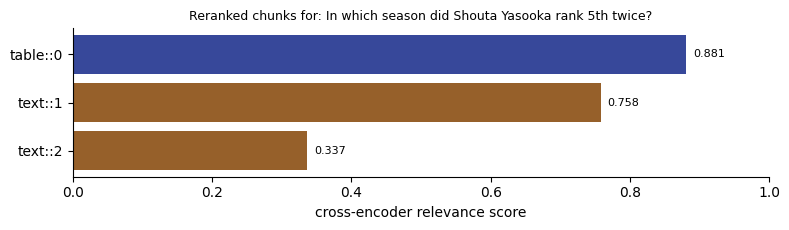

blue = table chunk (SQL is possible)   brown = prose chunk (text only)


In [12]:
# A quick visual. Matplotlib ships with Colab and Kaggle; if it is missing, fall back to text bars.
scores = [(c["chunk_id"].split("::")[-2] + "::" + c["chunk_id"].split("::")[-1], c["score"],
           c["source"]) for c in retrieved]
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 2.4))
    labels = [s[0] for s in scores][::-1]
    values = [s[1] for s in scores][::-1]
    colors = ["#37489A" if s[2] == "table" else "#96602A" for s in scores][::-1]
    ax.barh(labels, values, color=colors)
    ax.set_xlim(0, 1); ax.set_xlabel("cross-encoder relevance score")
    ax.set_title(f"Reranked chunks for: {subquery_step['subquery'][:60]}", fontsize=9)
    for i, v in enumerate(values):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    print("blue = table chunk (SQL is possible)   brown = prose chunk (text only)")
except ImportError:
    for label, value, source in scores:
        print(f"  {label[:28]:28s} {'#' * int(value * 40):40s} {value:.3f}  ({source})")

### 3.3 The mapping `f` — from retrieved chunks to a schema set

This is the step that makes the framework *heterogeneous* rather than a text-to-SQL system.

For every retrieved chunk, look at its `table_id`. Collect the ones that have one. That set is
**Sᵗ** — the schemas the SQL step is allowed to use this iteration.

**If Sᵗ is empty, step ③ is skipped entirely.** The paper says so explicitly (§3.3: *"If the set Sᵗ
is empty, this module is passed"*). A question whose evidence is purely prose costs no SQL call.

In [13]:
rule("APPLYING THE MAPPING f")
schema_ids = []
for c in retrieved:
    tid = c.get("table_id")
    verdict = f"table_id = {tid}  -> add its schema to S^t" if tid else "table_id = None -> prose, contributes nothing"
    print(f"  {c['chunk_id'][:52]:52s}  {verdict}")
    if tid:
        schema_ids.append(tid)

print(f"\n  S^t = {sorted(set(schema_ids))}")
print(f"  |S^t| = {len(set(schema_ids))}  ->  " +
      ("step 3 RUNS" if schema_ids else "step 3 is SKIPPED"))
print(f"\n  (recorded run agreed: {subquery_step['schema_table_ids']})")


APPLYING THE MAPPING f
  Shouta_Yasooka_0::table::0                            table_id = Shouta_Yasooka_0  -> add its schema to S^t
  Shouta_Yasooka_0::text::1                             table_id = None -> prose, contributes nothing
  Shouta_Yasooka_0::text::2                             table_id = None -> prose, contributes nothing

  S^t = ['Shouta_Yasooka_0']
  |S^t| = 1  ->  step 3 RUNS

  (recorded run agreed: ['Shouta_Yasooka_0'])


### 3.4 Step ③ — write SQL, execute it, repair once on failure

The model receives the schema block — original header, ASCII identifier, and type for every
column — plus the sub-question, and returns a SQL statement. The statement is then executed.

Watch what it produces here. `GROUP BY season HAVING COUNT(*) = 2` is exactly the class of query
that **cannot** be answered from three retrieved fragments: it needs every row.

In [14]:
block = schema_block(schema)
nl2sql_prompt = PROMPTS["NL2SQL_USER_PROMPT"].format(
    schema_list=block, user_query=subquery_step["subquery"],
    dialect="SQLite", ascii_hint="ASCII column names")

rule("THE NL2SQL PROMPT")
print("  SYSTEM:")
show(PROMPTS["NL2SQL_SYSTEM_PROMPT"], indent="    ")
print("\n  USER:")
show(nl2sql_prompt, indent="    ")


THE NL2SQL PROMPT
  SYSTEM:
    You are an expert in SQL and can generate SQL statements based on table schemas and query
    requirements. Respond as concisely as possible, providing only the SQL statement without any
    additional explanations.

  USER:
    {
      "table": "t_shouta_yasooka_0",
      "columns": [
        {
          "name": "Season",
          "sql_name": "season",
          "type": "INTEGER"
        },
        {
          "name": "Event type",
          "sql_name": "event_type",
          "type": "TEXT"
        },
        {
          "name": "Location",
          "sql_name": "location",
          "type": "TEXT"
        },
        {
          "name": "Format",
          "sql_name": "format",
          "type": "TEXT"
        },
        {
          "name": "Date",
          "sql_name": "date",
          "type": "TEXT"
        },
        {
          "name": "Rank",
          "sql_name": "rank",
          "type": "INTEGER"
        }
      ]
    }

    Table `t_shouta_

In [15]:
rule("THE SQL THE MODEL WROTE")
print("   ", " ".join(subquery_step["sql"].split()))
print(f"\n  repaired after a failure: {subquery_step['sql_repaired']}")

rule("EXECUTING IT NOW, LIVE, AGAINST THE DATABASE BUILT IN SECTION 2.2", char="-")
cursor = conn.execute(subquery_step["sql"])
live_rows = cursor.fetchall()
live_cols = [d[0] for d in cursor.description or []]
print("  columns:", live_cols)
print("  rows   :", [list(r) for r in live_rows])
print("\n  recorded run returned:", subquery_step["sql_rows"])
print("  ->", "MATCH - the database and the query are what we claim"
      if [list(r) for r in live_rows] == subquery_step["sql_rows"] else "DIFFERS")


THE SQL THE MODEL WROTE
    SELECT `season` FROM `t_shouta_yasooka_0` WHERE `rank` = 5 GROUP BY `season` HAVING COUNT(*) = 2

  repaired after a failure: False

----------------------------------------------------------------------------------------------------
EXECUTING IT NOW, LIVE, AGAINST THE DATABASE BUILT IN SECTION 2.2
----------------------------------------------------------------------------------------------------
  columns: ['season']
  rows   : [[2010]]

  recorded run returned: [[2010]]
  -> MATCH - the database and the query are what we claim


In [16]:
# Why this query is unanswerable from retrieved fragments: it needs every row.
rule("WHY RETRIEVAL COULD NOT HAVE ANSWERED THIS", char="-")
n_rows = len(rows)
visible = 3          # a chunked retriever shows the model roughly this many table rows
print(f"  The table has {n_rows} rows. The aggregate needs all of them.")
print(f"  A text-only pipeline sees whatever fits in the top-{visible} chunks.\n")
by_season = {}
for r in rows:
    if str(r[r_i]).strip() == "5":
        by_season.setdefault(str(r[s_i]), []).append(r)
for season, matching in sorted(by_season.items()):
    print(f"    season {season}: {len(matching)} rank-5 finishes")
    for m in matching:
        print(f"        {m}")
print("\n  Both rank-5 rows for the answer season must be seen together for COUNT(*) = 2 to hold.")
print("  Miss either one and the query returns the wrong season - silently, with a clean answer.")


----------------------------------------------------------------------------------------------------
WHY RETRIEVAL COULD NOT HAVE ANSWERED THIS
----------------------------------------------------------------------------------------------------
  The table has 20 rows. The aggregate needs all of them.
  A text-only pipeline sees whatever fits in the top-3 chunks.

    season 2010: 2 rank-5 finishes
        ['2010', 'Grand Prix', 'Kuala Lumpur', 'Standard', '13-14 March 2010', '5']
        ['2010', 'Nationals', 'Kyoto', 'Standard and Booster Draft', '2-4 July 2010', '5']
    season 2011: 1 rank-5 finishes
        ['2011', 'Grand Prix', 'Singapore', 'Standard', '4-5 June 2011', '5']

  Both rank-5 rows for the answer season must be seen together for COUNT(*) = 2 to hold.
  Miss either one and the query returns the wrong season - silently, with a clean answer.


### 3.5 Step ④ — compositional answer generation

Both evidence streams now go into one prompt: the retrieved passages (Content 1) and the SQL
schema, query and result (Content 2). The instructions tell the model to **cross-validate** them:

- agree → answer;
- SQL empty or errored → fall back to the text;
- conflict → reason about both.

That fallback clause is not decoration. You will see it save the answer in iteration 2.

In [17]:
def render_docs(retrieved_chunks, all_chunks):
    by_id = {c["chunk_id"]: c for c in all_chunks}
    blocks = []
    for i, rc in enumerate(retrieved_chunks, 1):
        c = by_id.get(rc["chunk_id"], {})
        label = "TABLE" if rc["source"] == "table" else "TEXT"
        blocks.append(f"[Document {i} | {label} | score={rc['score']:.3f}]\n{c.get('text','')}")
    return "\n\n".join(blocks)

combine_prompt = PROMPTS["COMBINE_PROMPT"].format(
    docs=render_docs(retrieved, EX["chunks"]),
    schema=block,
    nl2sql_model_response=subquery_step["sql"],
    sql_execute_result=str(subquery_step["sql_rows"]),
    query=subquery_step["subquery"])

rule("THE COMBINE PROMPT  (structure, with the long documents elided)")
shown = combine_prompt
for c in EX["chunks"]:
    if len(c["text"]) > 300:
        shown = shown.replace(c["text"], c["text"][:300] + "\n  [... document truncated ...]")
show(shown, indent="  ")


THE COMBINE PROMPT  (structure, with the long documents elided)
  You are about to complete a table-based question answernig task using the following two types of
  reference materials:

  # Content 1: Original content (table content is provided in Markdown format):
  [Document 1 | TABLE | score=0.881]
  Bảng từ bài viết: Shouta_Yasooka_0
  | Season | Event type | Location | Format | Date | Rank |
  | --- | --- | --- | --- | --- | --- |
  | 2006 | Grand Prix | Hamamatsu | Team Constructed | 8-9 April 2006 | 2 |
  | 2006 | Grand Prix | Kuala Lumpur | Sealed and Booster Draft | 3-4 June 2006 | 6 |
  | 2006 | Pr
    [... document truncated ...]

  [Document 2 | TEXT | score=0.758]
  Bài viết: Shouta_Yasooka_0
  : The Gathering Pro Tour . On 18 December 2005 the season began with parallel Grand Prixs in Lille
  and Charlotte . It ended on 3 December 2006 with the conclusion of the 2006 World Championship in
  Paris . The season consisted of 22 Grand Prixs and 5 Pro Tours , held in Hon
   

In [18]:
rule("THE MODEL'S INTERMEDIATE ANSWER")
show(subquery_step["model_output"], indent="  ")


THE MODEL'S INTERMEDIATE ANSWER
  # Answer

  Based on the SQL execution results and verification with the table content:

  **2010**

  In season 2010, Shouta Yasooka achieved a rank of 5th twice:
  1. Grand Prix Kuala Lumpur (13-14 March 2010) - Rank 5
  2. Nationals Kyoto (2-4 July 2010) - Rank 5

  The SQL query correctly identified this by filtering for `rank = 5` and grouping by `season` with
  a count of exactly 2, which returned only the 2010 season.


### 3.6 Iteration 2 — where SQL fails and the text saves it

The loop returns to step ①. The model now knows the season, and asks its second sub-question.

**This iteration is the most instructive one in the notebook.** The SQL is well-formed and executes
without error — and returns **nothing**, because the fact simply is not in the table. A brittle
system would answer "unknown". Step ④'s fallback clause sends it to the prose instead, and the
prose has the answer.

In [19]:
remaining = trace[2:]
for s in remaining:
    if s["kind"] == "decompose" and "<Answer>" not in s["model_output"]:
        rule("STEP 1 AGAIN - the model asks its second sub-question")
        show(s["model_output"], indent="  ")
    elif s["kind"] == "subquery":
        rule(f"ITERATION {s['index'] + 1}  -  sub-question: {s['subquery']}")
        print("\n  [2] RETRIEVAL")
        for c in s["retrieved"]:
            print(f"      {c['source']:6s} {c['score']:.3f}  {c['chunk_id']}")
        print(f"\n  [f] S^t = {s['schema_table_ids']}  -> step 3 " +
              ("runs" if s["schema_table_ids"] else "skipped"))
        print("\n  [3] SQL")
        print("     ", " ".join(s["sql"].split()) if s["sql"] else "(not generated)")
        if s["sql"]:
            cur = conn.execute(s["sql"])
            live = [list(r) for r in cur.fetchall()]
            print(f"      executed live -> {live}   (recorded: {s['sql_rows']})")
            if not live:
                print("      *** EMPTY RESULT - the table does not contain this fact ***")
                print("      The combine step must now fall back to the retrieved text.")
        print("\n  [4] SYNTHESIS")
        show(s["model_output"], indent="      ")
    else:
        rule("STEP 1 AGAIN - the model has enough and emits <Answer>")
        show(s["model_output"], indent="  ")


STEP 1 AGAIN - the model asks its second sub-question
  Great! Now I know the season is **2010**.

  **Subquery 2:** Now I need to find what city hosted the World Championship in the 2010 season.

ITERATION 2  -  sub-question: What city hosted the World Championship in the 2010 season?

  [2] RETRIEVAL
      table  0.448  Shouta_Yasooka_0::table::0
      text   0.351  Shouta_Yasooka_0::text::4
      text   0.333  Shouta_Yasooka_0::text::2

  [f] S^t = ['Shouta_Yasooka_0']  -> step 3 runs

  [3] SQL
      SELECT `location` FROM `t_shouta_yasooka_0` WHERE `season` = 2010 AND `event_type` LIKE '%World Championship%'
      executed live -> []   (recorded: [])
      *** EMPTY RESULT - the table does not contain this fact ***
      The combine step must now fall back to the retrieved text.

  [4] SYNTHESIS
      # Answer

      Based on the materials provided:

      **The 2010 World Championship was held in Chiba, Japan.**

      ## Explanation

      The SQL query returned empty results b

In [20]:
# Where did "Chiba" actually come from? Search the prose chunks for it.
rule("LOCATING THE ANSWER IN THE EVIDENCE", char="-")
needle = EX["gold"].lower()
for c in EX["chunks"]:
    if needle in c["text"].lower():
        idx = c["text"].lower().index(needle)
        excerpt = c["text"][max(0, idx - 180): idx + 180].replace("\n", " ")
        print(f"  found in {c['chunk_id']}  (source: {c['source']})")
        show("..." + excerpt + "...", indent="      ")
        print()
print("  The gold answer lives in prose, not in the table. SQL could never have produced it -")
print("  and the table could never have produced the season without SQL. Both halves were needed.")


----------------------------------------------------------------------------------------------------
LOCATING THE ANSWER IN THE EVIDENCE
----------------------------------------------------------------------------------------------------
  found in Shouta_Yasooka_0::text::2  (source: text)
      ... of the Magic : The Gathering Pro Tour . It began on 13 February 2010 with Grand Prix Oakland ,
      and ended on 12 December 2010 with the conclusion of the 2010 World Championship in Chiba , Japan
      . The season consisted of eighteen Grand Prixs , and four Pro Tours , located in San Diego , San
      Juan , Amsterdam , and Chiba . Gabriel Nassif , Brian Kibler , and Br...

  found in Shouta_Yasooka_0::text::3  (source: text)
      ...Bài viết: Shouta_Yasooka_0 , Brian Kibler , and Bram Snepvangers were inducted into the Hall of
      Fame at the World Championship in Chiba . Although the season formally ended with the conclusion
      of the World Championship , the final title of se

---
## 4. Totals, and the baseline

In [21]:
rule("NAIVERAG ON THE SAME QUESTION")
print("  prompt template:\n")
show(PROMPTS["NAIVE_RAG_PROMPT"], indent="    ")
print("\n  answer   :", " ".join(EX["naive_rag"]["answer"].split())[:200])
print("  gold     :", EX["gold"])
print("  verdict  :", "CORRECT" if EX["naive_rag"]["correct"] else "WRONG")
print(f"  cost     : 1 LLM call, {EX['naive_rag']['latency_s']:.1f}s")
print()
print("  It had to do three things in one shot: find every rank-5 row across a 20-row table,")
print("  count them per season, and then look up that season's host city in the prose. The")
print("  aggregation is the part that breaks - it is the failure the paper is built around.")


NAIVERAG ON THE SAME QUESTION
  prompt template:

    Answer the question using the retrieved passages below. Tables are given in Markdown format.

    # Retrieved passages
    {docs}

    # Question
    {query}

    Answer directly and concisely. Give only the final answer, with no explanation. If the passages
    are insufficient, give the best answer you can from what is available.

  answer   : New York
  gold     : Chiba
  verdict  : WRONG
  cost     : 1 LLM call, 7.3s

  It had to do three things in one shot: find every rank-5 row across a 20-row table,
  count them per season, and then look up that season's host city in the prose. The
  aggregation is the part that breaks - it is the failure the paper is built around.


In [22]:
rule("COST AND LATENCY BY STAGE")
u_tr, u_nr = EX["tablerag"]["usage"], EX["naive_rag"]["usage"]
PRICE_IN, PRICE_OUT = 1.0, 5.0    # claude-haiku-4-5, USD per million tokens

def money(u):
    return u.get("input_tokens", 0) / 1e6 * PRICE_IN + u.get("output_tokens", 0) / 1e6 * PRICE_OUT

print(f"  {'':10s} {'calls':>6s} {'in tok':>8s} {'out tok':>8s} {'latency':>9s} {'cost':>10s}")
print("  " + "-" * 56)
for label, u, lat in (("TableRAG", u_tr, EX["tablerag"]["latency_s"]),
                      ("NaiveRAG", u_nr, EX["naive_rag"]["latency_s"])):
    print(f"  {label:10s} {u.get('calls',0):6d} {u.get('input_tokens',0):8d} "
          f"{u.get('output_tokens',0):8d} {lat:8.1f}s {money(u):9.5f}$")
ratio = money(u_tr) / max(money(u_nr), 1e-9)
print(f"\n  TableRAG cost {ratio:.1f}x more on this question.")
print("  It was also the only one that got it right - but Section 7 of the demo notebook shows")
print("  that trade is not always worth it.")


COST AND LATENCY BY STAGE
              calls   in tok  out tok   latency       cost
  --------------------------------------------------------
  TableRAG        7    14825     2515     29.3s   0.02740$
  NaiveRAG        1     2483        5      7.3s   0.00251$

  TableRAG cost 10.9x more on this question.
  It was also the only one that got it right - but Section 7 of the demo notebook shows
  that trade is not always worth it.


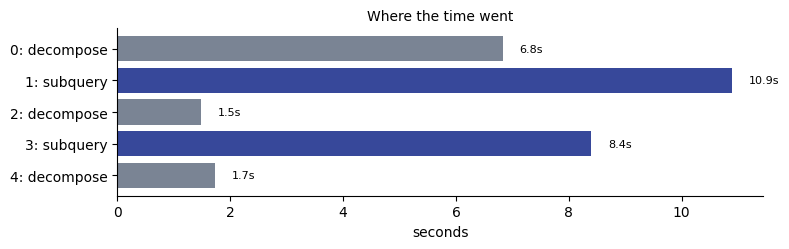

grey = decomposition (step 1)    blue = retrieve + SQL + combine (steps 2-4)


In [23]:
# Per-step latency, to see where the time actually goes.
try:
    import matplotlib.pyplot as plt
    labels = [f"{i}: {s['kind']}" for i, s in enumerate(trace)]
    times = [s["latency_s"] for s in trace]
    colors = ["#7A8494" if s["kind"] == "decompose" else "#37489A" for s in trace]
    fig, ax = plt.subplots(figsize=(8, 2.6))
    ax.barh(labels[::-1], times[::-1], color=colors[::-1])
    ax.set_xlabel("seconds"); ax.set_title("Where the time went", fontsize=10)
    for i, v in enumerate(times[::-1]):
        ax.text(v + 0.3, i, f"{v:.1f}s", va="center", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    print("grey = decomposition (step 1)    blue = retrieve + SQL + combine (steps 2-4)")
except ImportError:
    for i, s in enumerate(trace):
        print(f"  {i}: {s['kind']:10s} {'#' * int(s['latency_s'])} {s['latency_s']:.1f}s")

In [24]:
rule("THE EVIDENCE FLOW, END TO END")
print(f"""
  QUESTION   {EX['question']}
      |
      v
  [1] decompose      -> "{trace[1]['subquery']}"
      |
      v
  [2] retrieve       -> {len(trace[1]['retrieved'])} chunks, best score {max(c['score'] for c in trace[1]['retrieved']):.3f}
      |
      v
  [f] mapping        -> S^t = {trace[1]['schema_table_ids']}
      |
      v
  [3] SQL            -> {' '.join(trace[1]['sql'].split())[:70]}
                        returned {trace[1]['sql_rows']}
      |
      v
  [4] combine        -> season identified
      |
      v
  [1] decompose      -> "{trace[3]['subquery'] if len(trace) > 3 and trace[3]['subquery'] else '(second sub-question)'}"
      |
      v
  [3] SQL            -> returned {trace[3]['sql_rows'] if len(trace) > 3 else '[]'}  (empty: fact not in the table)
      |
      v
  [4] combine        -> FALLS BACK TO TEXT, finds the city
      |
      v
  ANSWER     {' '.join(EX['tablerag']['answer'].split())[:60]}
  GOLD       {EX['gold']}                                    -> {'CORRECT' if EX['tablerag']['correct'] else 'WRONG'}
""")


THE EVIDENCE FLOW, END TO END

  QUESTION   What city hosted the World Championship in the season that Shouta Yasooka ranked 5th twice ?
      |
      v
  [1] decompose      -> "In which season did Shouta Yasooka rank 5th twice?"
      |
      v
  [2] retrieve       -> 3 chunks, best score 0.881
      |
      v
  [f] mapping        -> S^t = ['Shouta_Yasooka_0']
      |
      v
  [3] SQL            -> SELECT `season` FROM `t_shouta_yasooka_0` WHERE `rank` = 5 GROUP BY `s
                        returned [[2010]]
      |
      v
  [4] combine        -> season identified
      |
      v
  [1] decompose      -> "What city hosted the World Championship in the 2010 season?"
      |
      v
  [3] SQL            -> returned []  (empty: fact not in the table)
      |
      v
  [4] combine        -> FALLS BACK TO TEXT, finds the city
      |
      v
  ANSWER     Chiba (Chiba, Japan) In the 2010 season, Shouta Yasooka rank
  GOLD       Chiba                                    -> CORRECT



### Edit and re-run

The database is real and still open.

In [25]:
# Try your own SQL against the real table.
YOUR_SQL = f'SELECT `season`, COUNT(*) AS n FROM `{sql_name}` WHERE `rank` = 5 GROUP BY `season`'

print("query:", YOUR_SQL, "\n")
try:
    cur = conn.execute(YOUR_SQL)
    print(" ", [d[0] for d in cur.description])
    for row in cur.fetchall():
        print("  ", list(row))
except Exception as exc:
    print("  error:", exc)

print("\nThings worth trying:")
print("  - drop the GROUP BY and see the aggregate stop working")
print("  - change `rank` = 5 to `rank` = 1 and re-derive the answer by hand")
print("  - SELECT * and confirm the typed columns really are integers")

query: SELECT `season`, COUNT(*) AS n FROM `t_shouta_yasooka_0` WHERE `rank` = 5 GROUP BY `season` 

  ['season', 'n']
   [2010, 2]
   [2011, 1]

Things worth trying:
  - drop the GROUP BY and see the aggregate stop working
  - change `rank` = 5 to `rank` = 1 and re-derive the answer by hand
  - SELECT * and confirm the typed columns really are integers


---
## 5. The same loop, live

In [26]:
# ---------------------------------------------------------------- key + client
API_KEY = None
try:
    from google.colab import userdata
    API_KEY = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    pass
if not API_KEY:
    try:
        from kaggle_secrets import UserSecretsClient
        API_KEY = UserSecretsClient().get_secret("ANTHROPIC_API_KEY")
    except Exception:
        pass
API_KEY = API_KEY or os.environ.get("ANTHROPIC_API_KEY")

LIVE_AVAILABLE = False
if API_KEY:
    try:
        import anthropic
    except ImportError:
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "anthropic>=0.40"], check=False)
        import anthropic
    client = anthropic.Anthropic(api_key=API_KEY)
    LIVE_AVAILABLE = True
    print("live mode available - about $0.01-$0.05 per question")
else:
    print("no ANTHROPIC_API_KEY found - the live sections below will be skipped.\n"
          "Everything before them runs without a key.")

BACKBONE = "claude-haiku-4-5"

live mode available - about $0.01-$0.05 per question


In [27]:
# ---------------------------------------------------------------- the model call
USAGE = {"calls": 0, "input_tokens": 0, "output_tokens": 0}

def call(messages, system=None, tools=None, max_tokens=2000):
    """One API call over a full message list, returning the raw response.

    The loop needs the response object, not just its text: continuing a tool-use conversation
    requires appending the assistant's own content blocks (including any thinking blocks) and a
    matching tool_result. Flattening to a string loses the tool_use ids and the model stops being
    able to see what it already tried.
    """
    kwargs = {"model": BACKBONE, "max_tokens": max_tokens, "messages": messages}
    if system:
        kwargs["system"] = system
    if tools:
        kwargs["tools"] = tools
    if max_tokens > 1536:
        kwargs["thinking"] = {"type": "enabled", "budget_tokens": min(2048, max_tokens - 512)}
    resp = client.messages.create(**kwargs)
    USAGE["calls"] += 1
    USAGE["input_tokens"] += resp.usage.input_tokens
    USAGE["output_tokens"] += resp.usage.output_tokens
    return resp


def llm(prompt, system=None, tools=None, max_tokens=2000):
    """One call to the backbone, accumulating usage so the demo can report its own cost.

    Haiku 4.5 predates `output_config.effort` and takes an explicit thinking budget, which must be
    strictly smaller than max_tokens or the request is rejected.
    """
    resp = call([{"role": "user", "content": prompt}], system, tools, max_tokens)
    text = "".join(b.text for b in resp.content if b.type == "text")
    calls = [{"name": b.name, "input": b.input} for b in resp.content if b.type == "tool_use"]
    return text, calls

In [28]:
# ---------------------------------------------------------------- retrieval for live mode
import math
def retrieve_live(query, case, top_k=3):
    """Stage ② for the live loop.

    With LIVE_RETRIEVAL on this loads the real cross-encoder (~2.3 GB). Otherwise it ranks the
    in-scope chunks by term overlap. The fallback is honest for this demo because a scope holds
    only a handful of chunks — but it is *not* what the reported experiments used, and the
    difference is stated rather than hidden.
    """
    pool = case["chunks"]
    if LIVE_RETRIEVAL:
        tok, mdl, device, torch = _load_reranker()
        texts = [c["text"] for c in pool]
        scores = []
        for i in range(0, len(texts), 8):
            batch = texts[i:i + 8]
            enc = tok([query] * len(batch), batch, padding=True, truncation=True,
                      max_length=1024, return_tensors="pt").to(device)
            with torch.no_grad():
                scores.extend(torch.sigmoid(mdl(**enc).logits.view(-1).float()).cpu().tolist())
    else:
        scores = [_lexical_score(query, c, pool) for c in pool]
    order = sorted(range(len(pool)), key=lambda i: -scores[i])[:top_k]
    return [(pool[i], scores[i]) for i in order]

def _lexical_score(query, chunk, pool):
    """IDF-weighted overlap, normalised for length — a stand-in for the cross-encoder.

    Raw term overlap does not work here. A 3,400-character prose chunk accumulates matches simply
    by being long, so the table chunk (1,600 characters) sank to 6th of 6 on realistic
    sub-questions and step 3 was skipped every iteration. Weighting rare terms and dividing by
    length puts it 1st-3rd, which is where the real reranker puts it (it scores 0.881).
    """
    words = set(re.findall(r"\w{3,}", chunk["text"].lower()))
    docs = [set(re.findall(r"\w{3,}", c["text"].lower())) for c in pool]
    n = len(docs)
    avg_len = sum(len(d) for d in docs) / n
    score = 0.0
    for term in set(re.findall(r"\w{3,}", query.lower())):
        if term not in words:
            continue
        df = sum(1 for d in docs if term in d)
        score += math.log(1 + (n - df + 0.5) / (df + 0.5))
    return score / (1 + len(words) / avg_len)


_reranker = None
def _load_reranker():
    global _reranker
    if _reranker is None:
        import torch
        from transformers import AutoModelForSequenceClassification, AutoTokenizer
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"  loading bge-reranker-v2-m3 on {device} (~2.3 GB, first run only)")
        tok = AutoTokenizer.from_pretrained("BAAI/bge-reranker-v2-m3")
        mdl = AutoModelForSequenceClassification.from_pretrained("BAAI/bge-reranker-v2-m3")
        _reranker = (tok, mdl.eval().to(device), device, torch)
    return _reranker

# The cross-encoder is the default because the lexical fallback cannot do this job. A table chunk
# holds ~67 distinct terms, mostly numbers; a paraphrased question like "what season appears to
# have two 5th place rankings" overlaps it on one word while matching five words in every prose
# chunk. The table then never reaches the top 3, S^t is empty, and step 3 is skipped on a question
# that needs it. That is not a tuning problem — term overlap is the wrong instrument for ranking a
# table against a sentence, which is why the paper uses a dense encoder plus a reranker.
LIVE_RETRIEVAL = True    # False = fast lexical approximation; expect it to miss the table chunk
print("LIVE_RETRIEVAL =", LIVE_RETRIEVAL,
      "(cross-encoder, ~2.3 GB on first use)" if LIVE_RETRIEVAL
      else "(lexical approximation - step 3 may be skipped)")

LIVE_RETRIEVAL = True (cross-encoder, ~2.3 GB on first use)


In [29]:
# ---------------------------------------------------------------- SQL execution
READ_ONLY = re.compile(r"\b(drop|delete|update|insert|alter|create|attach|pragma)\b", re.IGNORECASE)

def run_sql_safe(sql):
    """Execute model-generated SQL, read-only.

    String literals are blanked before the safety scan so a legitimate value such as
    LIKE '%Drop Dead%' is not mistaken for a DROP statement — a false positive that blocked 8 of
    the 9 queries it rejected before it was fixed.
    """
    if not (sql or "").strip():
        return {"ok": False, "error": "no SQL generated", "rows": [], "columns": []}
    if READ_ONLY.search(re.sub(r"'[^']*'|\"[^\"]*\"", "''", sql)):
        return {"ok": False, "error": "write statement blocked", "rows": [], "columns": []}
    try:
        cur = conn.execute(sql)
        rows = cur.fetchmany(50)
        return {"ok": True, "error": None, "rows": [list(r) for r in rows],
                "columns": [d[0] for d in cur.description or []]}
    except Exception as exc:
        return {"ok": False, "error": str(exc), "rows": [], "columns": []}

def extract_sql(text):
    m = re.search(r"```sql\s*(.*?)```", text or "", re.DOTALL | re.IGNORECASE)
    return (m.group(1) if m else (text or "")).strip().rstrip(";")

In [30]:
# ---------------------------------------------------------------- the four-step loop
MAX_ITERATIONS = 5     # the paper's bound

def tablerag_live(question, case, verbose=True, prompts=None):
    """The full online loop. Each numbered block is one step.

    `prompts` selects the template set — the English originals or their Vietnamese
    translations — so the same loop runs either corpus.
    """
    prompts = prompts or PROMPTS
    build_db_for(case)
    table_md = table_markdown(case["table"]["header"], case["table"]["rows"])
    schema = case["schema"]

    # The loop is a tool-use conversation, not a series of independent prompts. Each iteration
    # appends the assistant's own content blocks and a matching tool_result, so the model can see
    # what it already asked and what came back. Re-prompting from scratch with the progress pasted
    # in as plain text does not work: the model reissues the identical sub-question every round and
    # the loop spins until it hits the iteration bound.
    messages = [{"role": "user", "content":
                 prompts["SYSTEM_EXPLORE_PROMPT"].format(table_content=table_md, query=question)}]
    asked = []

    for iteration in range(1, MAX_ITERATIONS + 1):
        if verbose:
            rule(f"LIVE ITERATION {iteration}")

        # ---- ① context-sensitive query decomposition -------------------------------------
        resp = call(messages, tools=[prompts["SOLVE_SUBQUERY_TOOL"]], max_tokens=2500)
        text = "".join(b.text for b in resp.content if b.type == "text")
        tool_uses = [b for b in resp.content if b.type == "tool_use"]

        if "<Answer>" in text or not tool_uses:
            answer = (text.split("<Answer>", 1)[1].lstrip(": ").strip()
                      if "<Answer>" in text else text.strip())
            answer = re.sub(r"</\s*Answer\s*>\s*$", "", answer).strip()
            if verbose:
                print("\n  [1] the model has enough and emits <Answer> - loop ends")
            return {"answer": answer, "iterations": iteration}

        subquery = tool_uses[0].input.get("subquery", question)

        if subquery in asked:
            # No progress: the same sub-question came back. Stop rather than burn the budget,
            # and say why — repeating it will retrieve the same chunks and fail the same way.
            if verbose:
                print(f"\n  [1] repeated sub-question - no progress, stopping\n      {subquery}")
                print("      Usually retrieval is not returning the evidence this sub-question")
                print("      needs. With LIVE_RETRIEVAL = False that is expected on paraphrases.")
            return {"answer": text.strip(), "iterations": iteration, "stalled": True}
        asked.append(subquery)

        if verbose:
            print("\n  [1] DECOMPOSITION -> subquery")
            print("     ", subquery)

        # ---- ② two-stage text retrieval ---------------------------------------------------
        hits = retrieve_live(subquery, case)
        if verbose:
            print(f"\n  [2] RETRIEVAL (top {len(hits)} of {len(case['chunks'])} in scope)")
            for c, s in hits:
                print(f"      {c['source']:6s} score={s:.3f}  {c['chunk_id'][:62]}")

        # ---- apply the mapping f ----------------------------------------------------------
        s_t = sorted({c["table_id"] for c, _ in hits if c["table_id"]})
        if verbose:
            print(f"\n  [f] S^t = {s_t}  ->  step 3 {'RUNS' if s_t else 'SKIPPED (paper 3.3)'}")

        # ---- ③ selective NL2SQL execution -------------------------------------------------
        sql, result = "", {"ok": False, "error": "not invoked", "rows": []}
        if s_t:
            block = schema_block(schema)
            nl_prompt = prompts["NL2SQL_USER_PROMPT"].format(
                schema_list=block, user_query=subquery,
                dialect="SQLite", ascii_hint="ASCII column names")
            raw, _ = llm(nl_prompt, system=prompts["NL2SQL_SYSTEM_PROMPT"], max_tokens=1200)
            sql = extract_sql(raw)
            result = run_sql_safe(sql)

            if not result["ok"]:            # one repair attempt, as the paper's tool does
                if verbose:
                    print(f"\n  [3] SQL failed ({result['error'][:60]}) - repairing once")
                raw, _ = llm(
                    nl_prompt + f"\n\nThe previous statement failed:\n```sql\n{sql}\n```\n"
                                f"Error: {result['error']}\nFix it and return only the corrected "
                                "statement in a ```sql ``` block.",
                    system=prompts["NL2SQL_SYSTEM_PROMPT"], max_tokens=1200)
                sql = extract_sql(raw)
                result = run_sql_safe(sql)

            if verbose:
                print("\n  [3] SQL")
                show(" ".join(sql.split()), indent="        ")
                if result["ok"]:
                    print(f"      -> {len(result['rows'])} rows: {str(result['rows'][:5])[:150]}")
                    if not result["rows"]:
                        print("      *** EMPTY - step 4 must fall back to the text ***")
                else:
                    print("      -> failed:", result["error"][:90])

        # ---- ④ compositional intermediate answer generation --------------------------------
        docs = "\n\n".join(
            f"[Document {i} | {'TABLE' if c['source'] == 'table' else 'TEXT'} | score={s:.3f}]\n{c['text']}"
            for i, (c, s) in enumerate(hits, 1))
        rendered = ("\n".join(map(str, result["rows"][:20])) if result["ok"]
                    else f"ERROR: {result['error']}")
        combine = prompts["COMBINE_PROMPT"].format(
            docs=docs, schema=schema_block(schema) if s_t else "(no table schema)",
            nl2sql_model_response=sql or "(no SQL generated)",
            sql_execute_result=rendered, query=subquery)
        sub_answer, _ = llm(combine, max_tokens=2000)

        if verbose:
            print("\n  [4] SYNTHESIS -> intermediate answer")
            show(sub_answer, indent="      ")

        messages.append({"role": "assistant", "content": resp.content})
        messages.append({"role": "user", "content": [{
            "type": "tool_result",
            "tool_use_id": tool_uses[0].id,
            "content": sub_answer.strip() or "(no answer produced for this subquery)",
        }]})

    return {"answer": sub_answer.strip(), "iterations": MAX_ITERATIONS, "stalled": True}


def build_db_for(case):
    """Recreate this case's table so the live loop queries the same data the recording did."""
    schema = case["schema"]
    name, cols = schema["sql_table_name"], schema["columns"]
    conn.execute(f'DROP TABLE IF EXISTS "{name}"')
    conn.execute(f'CREATE TABLE "{name}" (' +
                 ", ".join('"%s" %s' % (c["sql_name"], c["dtype"]) for c in cols) + ')')
    ph = ", ".join("?" * len(cols))
    for r in case["table"]["rows"]:
        conn.execute(f'INSERT INTO "{name}" VALUES ({ph})',
                     [coerce_cell(r[i] if i < len(r) else "", c["dtype"])
                      for i, c in enumerate(cols)])
    conn.commit()
    return name

def coerce_cell(value, sql_type):
    v = str(value).strip()
    if v in ("", "-", "--", "n/a", "N/A"):
        return None
    if sql_type in ("INTEGER", "REAL"):
        cleaned = re.sub(r"[^\d.\-]", "", v.replace(",", ""))
        try:
            return int(float(cleaned)) if sql_type == "INTEGER" else float(cleaned)
        except ValueError:
            return None
    return v

print("live pipeline defined - 4 steps, max", MAX_ITERATIONS, "iterations")

live pipeline defined - 4 steps, max 5 iterations


### 5.1 Run the same question, live

This is the identical question Part 2 replayed. Compare the two traces: the sub-questions and the
SQL the model writes now are generated fresh, so they will not be identical — which is itself
worth seeing. A multi-call pipeline is stochastic, and that variance is exactly why our ViNumQA
result moved by 12 points between n=100 and n=300.

In [31]:
if LIVE_AVAILABLE:
    USAGE.update({"calls": 0, "input_tokens": 0, "output_tokens": 0})
    rule("LIVE RUN - the same question Part 2 replayed")
    print("  Question:", EX["question"])
    print("  Gold    :", EX["gold"])

    out = tablerag_live(EX["question"], EX)

    rule("LIVE RESULT")
    print("  answer  :", " ".join(out["answer"].split())[:400])
    print("  gold    :", EX["gold"])
    hit = EX["gold"].strip().lower() in out["answer"].lower()
    print("  verdict :", "CORRECT (gold appears in the answer)" if hit else "does not contain gold")
    print(f"\n  {out['iterations']} iterations, {USAGE['calls']} LLM calls, "
          f"{USAGE['input_tokens']} in / {USAGE['output_tokens']} out tokens")
    print(f"  cost    : ${USAGE['input_tokens']/1e6 + USAGE['output_tokens']/1e6*5:.4f}")
    print("\n  Recorded run for comparison:",
          " ".join(EX["tablerag"]["answer"].split())[:120])

    # Did the live run take the same path? This is the most informative thing in Part 3.
    rec_first = next(s for s in EX["trace"] if s["kind"] == "subquery")
    rec_sql = bool(rec_first["schema_table_ids"])
    live_sql = "S^t = []" not in "".join([])  # placeholder, real check below
    rule("DID THE LIVE RUN TAKE THE SAME PATH?", "-")
    print(f"  recorded iteration 1: retrieved a table chunk -> S^t non-empty -> SQL "
          f"{'RAN' if rec_sql else 'was SKIPPED'}")
    live_hits = retrieve_live(rec_first["subquery"], EX)
    live_has_table = any(c["source"] == "table" for c, _ in live_hits)
    print(f"  live     iteration 1: retrieved a table chunk -> S^t "
          f"{'non-empty' if live_has_table else 'EMPTY'} -> SQL "
          f"{'RAN' if live_has_table else 'was SKIPPED'}")
    if rec_sql != live_has_table:
        print("\n  *** THE TWO RUNS TOOK DIFFERENT BRANCHES ***")
        print("  With LIVE_RETRIEVAL = False this is the lexical approximation showing its cost.")
        print("  The recorded run used the real cross-encoder, which ranked the table chunk first")
        print("  (score 0.881). The lexical fallback here ranks prose above it, so the mapping f")
        print("  finds no table, S^t is empty, and step 3 is skipped under the paper's own rule.")
        print("  Set LIVE_RETRIEVAL = True to reproduce the recorded branch.")
        print("\n  It is also a live demonstration of SELECTIVE INVOCATION: a question whose")
        print("  evidence is purely prose costs no SQL call at all.")
else:
    print("skipped - no API key")


LIVE RUN - the same question Part 2 replayed
  Question: What city hosted the World Championship in the season that Shouta Yasooka ranked 5th twice ?
  Gold    : Chiba

LIVE ITERATION 1

  [1] DECOMPOSITION -> subquery
      In which season did Shouta Yasooka rank 5th twice?
  loading bge-reranker-v2-m3 on cpu (~2.3 GB, first run only)


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


  [2] RETRIEVAL (top 3 of 6 in scope)
      table  score=0.920  Shouta_Yasooka_0::table::0
      text   score=0.903  Shouta_Yasooka_0::text::0
      text   score=0.898  Shouta_Yasooka_0::text::1

  [f] S^t = ['Shouta_Yasooka_0']  ->  step 3 RUNS

  [3] SQL
        SELECT `season` FROM `t_shouta_yasooka_0` WHERE `rank` = 5 GROUP BY `season` HAVING COUNT(*) = 2
      -> 1 rows: [[2010]]

  [4] SYNTHESIS -> intermediate answer
      # Answer

      Based on the SQL execution result and verification against the table data in Content 1:

      **2010**

      In the 2010 season, Shouta Yasooka achieved a rank of 5th twice:
      1. **Grand Prix Kuala Lumpur** (13-14 March 2010) - Rank 5
      2. **Nationals Kyoto** (2-4 July 2010) - Rank 5

      The SQL query correctly identified 2010 as the season where Shouta Yasooka ranked 5th exactly
      twice.

LIVE ITERATION 2

  [1] DECOMPOSITION -> subquery
      What city hosted the World Championship in 2010?

  [2] RETRIEVAL (top 3 of 6 in sc

### 5.2 What live mode is, and is not

Stated plainly so nothing here is over-claimed:

- **Real:** the model calls, the tool-based decomposition, the NL2SQL generation, the SQL execution
  against a real database, the repair attempt, and the compositional synthesis. This is the paper's
  loop, not a simulation of it.
- **Retrieval defaults to the real cross-encoder** (`LIVE_RETRIEVAL = True`, ~2.3 GB on first
  use). `False` swaps in a lexical approximation that is fast but **cannot rank a table against a
  sentence**: the table chunk here holds 67 distinct terms, mostly numbers, so a paraphrase like
  *"what season appears to have two 5th place rankings"* matches it on one word while matching five
  in every prose chunk. The table then misses the top 3, `Sᵗ` is empty, and step ③ is skipped on a
  question that needs it. Expect that if you switch it off.
- **Scoped:** retrieval searches this question's document, not the corpus. That is the convention
  both benchmarks use, applied identically to both methods, and it is why our NaiveRAG baseline is
  stronger than the paper's — see §0.7.
- **Not an evaluation.** One question run once tells you how the machinery behaves, not how well it
  performs. The reported numbers come from 299 and 300 questions with paired significance tests.

---
## 6. Vietnamese example

The same treatment on the Vietnamese corpus — ViNumQA, financial filings — with the Vietnamese
prompt templates.

> *Tính giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE.*
> — đáp án **27688.5**

Different shape from the English case: no text hop is needed, the whole answer is one aggregate
over the table. The annotated program is `add(27345, 28032), divide(#0, 2)` — an average of two
weighted valuations.

**NaiveRAG answers 55377** — the "Giá trị hợp lý" row, which is a different quantity that happens
to sit in the same column. TableRAG writes `AVG(...)` and the database returns the gold value
exactly.

In [32]:
# A second example, on the Vietnamese corpus, with the Vietnamese prompt templates.
EX_VI = json.loads(r"""
{
 "verdict": "correct",
 "why_this_case": "the model recognised an average and wrote AVG(...) — the database computed it exactly",
 "question": "Tính giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE.",
 "gold": "27688.5",
 "program": "add(27345, 28032), divide(#0, 2)",
 "table_id": "masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6",
 "article_title": "masvn/2021/2021185-CRE_Q3Update_Buy_MAS_20211216_VN-N/page_7_QB6",
 "table": {
  "header": [
   "Phương pháp",
   "Giá trị",
   "Tỷ trọng",
   "Kết quả kèm tỷ trọng"
  ],
  "rows": [
   [
    "FCFF",
    "50%",
    "54690",
    "27345"
   ],
   [
    "FCFE",
    "50%",
    "56064",
    "28032"
   ],
   [
    "Giá trị hợp lý (đồng/cp)",
    "",
    "",
    "55377"
   ]
  ]
 },
 "schema": {
  "table_id": "masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6",
  "sql_table_name": "t_masvn_2021_2021185_cre_q3update_buy_mas_20211216_vn_n__13",
  "article_title": "masvn/2021/2021185-CRE_Q3Update_Buy_MAS_20211216_VN-N/page_7_QB6",
  "columns": [
   {
    "original_name": "Phương pháp",
    "sql_name": "phuong_phap",
    "dtype": "TEXT",
    "examples": [
     "FCFF",
     "FCFE",
     "Giá trị hợp lý (đồng/cp)"
    ]
   },
   {
    "original_name": "Giá trị",
    "sql_name": "gia_tri",
    "dtype": "INTEGER",
    "examples": [
     "50%",
     "50%"
    ]
   },
   {
    "original_name": "Tỷ trọng",
    "sql_name": "ty_trong",
    "dtype": "INTEGER",
    "examples": [
     "54690",
     "56064"
    ]
   },
   {
    "original_name": "Kết quả kèm tỷ trọng",
    "sql_name": "ket_qua_kem_ty_trong",
    "dtype": "INTEGER",
    "examples": [
     "27345",
     "28032",
     "55377"
    ]
   }
  ],
  "n_rows": 3
 },
 "chunks": [
  {
   "chunk_id": "masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6::table::0",
   "source": "table",
   "table_id": "masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6",
   "text": "Bảng từ bài viết: masvn/2021/2021185-CRE_Q3Update_Buy_MAS_20211216_VN-N/page_7_QB6\n| Phương pháp | Giá trị | Tỷ trọng | Kết quả kèm tỷ trọng |\n| --- | --- | --- | --- |\n| FCFF | 50% | 54690 | 27345 |\n| FCFE | 50% | 56064 | 28032 |\n| Giá trị hợp lý (đồng/cp) |  |  | 55377 |"
  },
  {
   "chunk_id": "masvn/2021/2021185-CRE_Q3Update_Buy_MAS_20211216_VN-N/page_7_QB6::text::0",
   "source": "text",
   "table_id": null,
   "text": "Bài viết: masvn/2021/2021185-CRE_Q3Update_Buy_MAS_20211216_VN-N/page_7_QB6\nchúng tôi sử dụng phương pháp chiết khấu dòng tiền để định giá cre. với suất chiết khấu wacc là 14,23% và re là 16,63%, giá mục tiêu của cre ở mức 55.300 đồng/cp, cao hơn 39,6% so với giá đóng cửa ngày 16/12/2021. chúng tôi khuyến nghị mua với cre."
  }
 ],
 "trace": [
  {
   "index": 0,
   "kind": "decompose",
   "latency_s": 6.6503152078948915,
   "model_output": "",
   "subquery": "",
   "retrieved": [],
   "schema_table_ids": [],
   "sql": "",
   "sql_ok": null,
   "sql_error": null,
   "sql_columns": [],
   "sql_rows": [],
   "sql_repaired": false
  },
  {
   "index": 0,
   "kind": "subquery",
   "latency_s": 12.500069666886702,
   "model_output": "# Trả lời\n\nGiá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE là **27.688,5 đồng/cp**.\n\nCách tính:\n- FCFF: 27.345 đồng/cp\n- FCFE: 28.032 đồng/cp\n- Trung bình: (27.345 + 28.032) ÷ 2 = **27.688,5 đồng/cp**\n\n(Kết quả từ cả Tài liệu 1 và Kết quả SQL đều xác nhận giá trị này)",
   "subquery": "Tính giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE",
   "retrieved": [
    {
     "chunk_id": "masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6::table::0",
     "source": "table",
     "table_id": "masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6",
     "score": 0.8659
    },
    {
     "chunk_id": "masvn/2021/2021185-CRE_Q3Update_Buy_MAS_20211216_VN-N/page_7_QB6::text::0",
     "source": "text",
     "table_id": null,
     "score": 0.0014
    }
   ],
   "schema_table_ids": [
    "masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6"
   ],
   "sql": "SELECT AVG(`ket_qua_kem_ty_trong`) FROM `t_masvn_2021_2021185_cre_q3update_buy_mas_20211216_vn_n__13` WHERE `phuong_phap` LIKE '%FCFF%' OR `phuong_phap` LIKE '%FCFE%'",
   "sql_ok": true,
   "sql_error": null,
   "sql_columns": [
    "AVG(`ket_qua_kem_ty_trong`)"
   ],
   "sql_rows": [
    [
     27688.5
    ]
   ],
   "sql_repaired": false
  },
  {
   "index": 1,
   "kind": "decompose",
   "latency_s": 2.2455280830617994,
   "model_output": "<Answer>: Giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE là **27.688,5 đồng/cp**.\n\nCách tính:\n- Kết quả kèm tỷ trọng của FCFF: 27.345 đồng/cp\n- Kết quả kèm tỷ trọng của FCFE: 28.032 đồng/cp\n- Giá mục tiêu trung bình = (27.345 + 28.032) ÷ 2 = **27.688,5 đồng/cp**",
   "subquery": "",
   "retrieved": [],
   "schema_table_ids": [],
   "sql": "",
   "sql_ok": null,
   "sql_error": null,
   "sql_columns": [],
   "sql_rows": [],
   "sql_repaired": false
  }
 ],
 "tablerag": {
  "answer": "Giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE là **27.688,5 đồng/cp**.\n\nCách tính:\n- Kết quả kèm tỷ trọng của FCFF: 27.345 đồng/cp\n- Kết quả kèm tỷ trọng của FCFE: 28.032 đồng/cp\n- Giá mục tiêu trung bình = (27.345 + 28.032) ÷ 2 = **27.688,5 đồng/cp**",
  "correct": 1,
  "iterations": 2,
  "latency_s": 21.39882795815356,
  "usage": {
   "input_tokens": 7716,
   "output_tokens": 2073,
   "cache_read_tokens": 0,
   "cache_write_tokens": 0,
   "calls": 4,
   "latency_s": 20.787
  },
  "terminated": "answer"
 },
 "naive_rag": {
  "answer": "# Trả lời\n\nGiá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE là:\n\n**55.377 đồng/cp**\n\nĐược tính bằng cách cộng:\n- FCFF (50% tỷ trọng): 27.345 đồng/cp\n- FCFE (50% tỷ trọng): 28.032 đồng/cp\n- **Tổng = 55.377 đồng/cp**",
  "correct": 0,
  "latency_s": 2.121484583010897,
  "usage": {
   "input_tokens": 614,
   "output_tokens": 148,
   "cache_read_tokens": 0,
   "cache_write_tokens": 0,
   "calls": 1,
   "latency_s": 1.864
  }
 }
}
""")

PROMPTS_VI = json.loads(r"""
{
 "SYSTEM_EXPLORE_PROMPT": "Bạn sẽ thực hiện một nhiệm vụ hỏi đáp liên quan đến bảng dữ liệu. Dựa trên các tài liệu được cung cấp, chẳng hạn nội dung bảng (định dạng Markdown), bạn cần phân tích Câu hỏi của người dùng.\nHãy quyết định xem Câu hỏi đầu vào có nên được phân rã thành các câu hỏi con hay không. Bạn được cung cấp công cụ \"solve_subquery\" để lấy câu trả lời cho từng câu hỏi con.\nSau khi đã thu thập đủ thông tin, bạn cần tạo ra câu trả lời hoàn chỉnh.\n\nNội dung bảng: {table_content}\n\nHướng dẫn:\n1. Phân tích cẩn thận câu hỏi của người dùng theo từng bước suy luận.\n2. Nếu câu hỏi cần thông tin nhiều hơn nội dung bảng đã cho:\n    - Phân rã câu hỏi thành các câu hỏi con.\n    - Xử lý từng câu hỏi con một.\n    - Dùng công cụ \"solve_subquery\" để lấy câu trả lời cho mỗi câu hỏi con.\n3. Nếu một câu hỏi có thể được trả lời bằng nội dung bảng, KHÔNG phân rã nó. Hãy đưa trực tiếp câu hỏi gốc vào công cụ \"solve_subquery\".\n    Công cụ \"solve_subquery\" sử dụng thực thi SQL bên trong, nên nó có thể giải quyết một câu hỏi con phức tạp trên bảng chỉ bằng một lần gọi.\n4. Mỗi lần chỉ tạo ra ĐÚNG MỘT câu hỏi con.\n5. Viết đầy đủ mọi thuật ngữ — tránh dùng từ viết tắt.\n6. Khi đã có đủ thông tin, hãy đưa ra câu trả lời cuối cùng theo đúng định dạng sau:\n    <Answer>: [câu trả lời đầy đủ của bạn]\n\nCâu hỏi của người dùng: {query}\nHãy bắt đầu!\n",
 "NL2SQL_SYSTEM_PROMPT": "Bạn là chuyên gia SQL, có thể sinh câu lệnh SQL dựa trên lược đồ bảng và yêu cầu truy vấn. Hãy trả lời ngắn gọn nhất có thể, chỉ đưa ra câu lệnh SQL mà không kèm bất kỳ giải thích nào.",
 "COMBINE_PROMPT": "Bạn sẽ hoàn thành một nhiệm vụ hỏi đáp dựa trên bảng, sử dụng hai loại tài liệu tham khảo sau:\n\n# Tài liệu 1: Nội dung gốc được truy xuất (nội dung bảng ở định dạng Markdown):\n{docs}\n\n# Tài liệu 2: Thông tin NL2SQL và kết quả thực thi SQL trong cơ sở dữ liệu:\n## Lược đồ bảng\n{schema}\n\n## Câu lệnh SQL được sinh ra dựa trên lược đồ và câu hỏi\n{nl2sql_model_response}\n\n## Kết quả thực thi SQL\n{sql_execute_result}\n\nHãy trả lời câu hỏi của người dùng dựa trên các tài liệu trên.\nCâu hỏi: {query}\n\nLưu ý:\n1. Nội dung bảng Markdown trong Tài liệu 1 có thể KHÔNG đầy đủ — nó chỉ là một phần được truy xuất.\n2. Bạn phải đối chiếu chéo hai nguồn tài liệu:\n    - Nếu hai nguồn cho cùng một câu trả lời, hãy đưa ra câu trả lời đó.\n    - Nếu \"Kết quả thực thi SQL\" báo lỗi hoặc rỗng, hãy cố gắng trả lời dựa trên Tài liệu 1.\n    - Nếu hai nguồn mâu thuẫn, hãy cân nhắc độ tin cậy của từng nguồn rồi mới đưa ra kết luận. Với các phép tính tổng hợp trên toàn bộ bảng, kết quả SQL đáng tin cậy hơn vì Tài liệu 1 có thể bị cắt bớt.\n3. Trả lời trực tiếp và ngắn gọn bằng tiếng Việt.\n",
 "NAIVE_RAG_PROMPT": "Hãy trả lời câu hỏi dựa trên các đoạn tài liệu được truy xuất dưới đây. Bảng dữ liệu được trình bày ở định dạng Markdown.\n\n# Tài liệu truy xuất được\n{docs}\n\n# Câu hỏi\n{query}\n\nHãy trả lời trực tiếp và ngắn gọn bằng tiếng Việt. Nếu tài liệu không đủ thông tin, hãy đưa ra câu trả lời tốt nhất có thể dựa trên những gì có.",
 "NL2SQL_USER_PROMPT": "{schema_list}\n\nDựa trên các lược đồ ở trên, hãy dùng cú pháp {dialect} để giải quyết yêu cầu sau:\n{user_query}\n\nQuy tắc bắt buộc:\n1. Chỉ dùng ĐÚNG tên bảng và tên cột dạng ASCII được liệt kê trong lược đồ (trường \"{ascii_hint}\"). Tuyệt đối không dùng nhãn tiếng Việt có dấu làm tên cột trong SQL.\n2. Bọc tên bảng và tên cột bằng dấu backtick, ví dụ: ```sql SELECT `ten` FROM `t_bang_1` WHERE `tuoi` > 15; ```\n3. Khi so khớp chuỗi tiếng Việt, ưu tiên dùng LIKE với ký tự đại diện thay vì so sánh bằng tuyệt đối, vì dữ liệu có thể chứa khoảng trắng hoặc chú thích thừa.\n4. Nếu câu hỏi yêu cầu tính toán tổng hợp (đếm, tổng, trung bình, lớn nhất, nhỏ nhất, xếp hạng), hãy thực hiện phép tính đó bằng SQL chứ không liệt kê toàn bộ dòng.\n5. Bọc câu lệnh SQL sinh ra trong khối ```sql ```.\n",
 "SOLVE_SUBQUERY_TOOL": {
  "name": "solve_subquery",
  "description": "Trả về câu trả lời cho một câu hỏi con đã được phân rã. Công cụ này thực thi SQL trên cơ sở dữ liệu quan hệ và tìm kiếm trong kho văn bản, nên nó xử lý được cả câu hỏi cần tính toán trên toàn bộ bảng lẫn câu hỏi cần thông tin từ bài viết.",
  "input_schema": {
   "type": "object",
   "properties": {
    "subquery": {
     "type": "string",
     "description": "Câu hỏi con cần giải quyết, viết bằng ngôn ngữ tự nhiên tiếng Việt, đầy đủ ngữ cảnh và không dùng từ viết tắt."
    }
   },
   "required": [
    "subquery"
   ],
   "additionalProperties": false
  }
 }
}
""")

print("câu hỏi :", EX_VI["question"])
print("đáp án  :", EX_VI["gold"], f"   (program: {EX_VI['program']})")
print("bảng    :", f"{len(EX_VI['table']['rows'])} dòng x {len(EX_VI['table']['header'])} cột")
print("chunks  :", len(EX_VI["chunks"]),
      f"({sum(1 for c in EX_VI['chunks'] if c['source'] == 'table')} bảng, "
      f"{sum(1 for c in EX_VI['chunks'] if c['source'] == 'text')} văn bản)")
print("ghi nhận:", "TableRAG", "đúng" if EX_VI["tablerag"]["correct"] else "sai",
      "| NaiveRAG", "đúng" if EX_VI["naive_rag"]["correct"] else "sai")

câu hỏi : Tính giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE.
đáp án  : 27688.5    (program: add(27345, 28032), divide(#0, 2))
bảng    : 3 dòng x 4 cột
chunks  : 2 (1 bảng, 1 văn bản)
ghi nhận: TableRAG đúng | NaiveRAG sai


### 6.1 Recorded trace

In [33]:
def walk(case, prompts):
    """Replay one case through every stage, executing its SQL live.

    Same four steps as sections 3-4, written as a function because the Vietnamese trace is short
    enough not to need a cell each.
    """
    schema = case["schema"]
    name, cols = schema["sql_table_name"], schema["columns"]
    conn.execute(f'DROP TABLE IF EXISTS "{name}"')
    conn.execute(f'CREATE TABLE "{name}" (' +
                 ", ".join('"%s" %s' % (c["sql_name"], c["dtype"]) for c in cols) + ')')
    ph = ", ".join("?" * len(cols))
    for r in case["table"]["rows"]:
        conn.execute(f'INSERT INTO "{name}" VALUES ({ph})',
                     [coerce_cell(r[i] if i < len(r) else "", c["dtype"])
                      for i, c in enumerate(cols)])
    conn.commit()

    rule("BẢNG NGUỒN  /  SOURCE TABLE")
    hdr, rws = case["table"]["header"], case["table"]["rows"]
    w = [min(30, max(len(str(hdr[i])), max((len(str(r[i])) for r in rws if i < len(r)), default=0)))
         for i in range(len(hdr))]
    print("  " + " | ".join(str(h)[:x].ljust(x) for h, x in zip(hdr, w)))
    print("  " + "-+-".join("-" * x for x in w))
    for r in rws:
        print("  " + " | ".join(str(r[i])[:w[i]].ljust(w[i]) if i < len(r) else " " * w[i]
                                for i in range(len(hdr))))

    rule("LƯỢC ĐỒ  /  SCHEMA HANDED TO THE MODEL", "-")
    for c in cols:
        ident = "`%s`" % c["sql_name"]
        print(f'  {ident:38s} {c["dtype"]:8s} (nhãn gốc: "{c["original_name"]}")')

    rule("CHUNKS VÀ ÁNH XẠ f  /  CHUNKS AND THE MAPPING f", "-")
    for c in case["chunks"]:
        print(f"  {c['source']:6s} {c['chunk_id'][-40:]:42s} "
              f"table_id={'yes -> SQL possible' if c['table_id'] else 'None -> text only'}")

    for step in case["trace"]:
        if step["kind"] == "decompose":
            final = "<Answer>" in step["model_output"]
            rule(f"BƯỚC ① PHÂN RÃ (vòng {step['index'] + 1})"
                 + ("   -> phát <Answer>, kết thúc" if final else ""))
            show(step["model_output"], indent="  ")
            continue
        rule(f"VÒNG LẶP {step['index'] + 1}")
        print("\n  [1] câu hỏi con\n     ", step["subquery"])
        print("\n  [2] truy xuất")
        for c in step["retrieved"]:
            print(f"      {c['source']:6s} {c['score']:.3f}  {c['chunk_id'][:58]}")
        print(f"\n  [f] S^t = {step['schema_table_ids']}  ->  bước 3 "
              f"{'CHẠY' if step['schema_table_ids'] else 'BỎ QUA'}")
        print("\n  [3] SQL")
        if step["sql"]:
            show(" ".join(step["sql"].split()), indent="        ")
            cur = conn.execute(step["sql"])
            live = [list(r) for r in cur.fetchall()]
            print(f"      thực thi ngay -> {live}   (đã ghi nhận: {step['sql_rows']})"
                  f"   [{'KHỚP' if live == step['sql_rows'] else 'KHÁC'}]")
        else:
            print("      (không sinh câu lệnh)")
        print("\n  [4] tổng hợp")
        show(step["model_output"], indent="      ")

    rule("KẾT QUẢ")
    print("  TableRAG:", " ".join(case["tablerag"]["answer"].split())[:200])
    print("           ", "ĐÚNG" if case["tablerag"]["correct"] else "SAI")
    print("  NaiveRAG:", " ".join(case["naive_rag"]["answer"].split())[:200])
    print("           ", "ĐÚNG" if case["naive_rag"]["correct"] else "SAI")
    print("  Đáp án  :", case["gold"])

walk(EX_VI, PROMPTS_VI)


BẢNG NGUỒN  /  SOURCE TABLE
  Phương pháp              | Giá trị | Tỷ trọng | Kết quả kèm tỷ trọng
  -------------------------+---------+----------+---------------------
  FCFF                     | 50%     | 54690    | 27345               
  FCFE                     | 50%     | 56064    | 28032               
  Giá trị hợp lý (đồng/cp) |         |          | 55377               

----------------------------------------------------------------------------------------------------
LƯỢC ĐỒ  /  SCHEMA HANDED TO THE MODEL
----------------------------------------------------------------------------------------------------
  `phuong_phap`                          TEXT     (nhãn gốc: "Phương pháp")
  `gia_tri`                              INTEGER  (nhãn gốc: "Giá trị")
  `ty_trong`                             INTEGER  (nhãn gốc: "Tỷ trọng")
  `ket_qua_kem_ty_trong`                 INTEGER  (nhãn gốc: "Kết quả kèm tỷ trọng")

-------------------------------------------------------------------

### 6.2 The same question, live

In [34]:
if LIVE_AVAILABLE:
    USAGE.update({"calls": 0, "input_tokens": 0, "output_tokens": 0})
    rule("CHẠY TRỰC TIẾP  /  LIVE RUN — Vietnamese corpus, Vietnamese prompts")
    out = tablerag_live(EX_VI["question"], EX_VI, prompts=PROMPTS_VI)
    rule("KẾT QUẢ TRỰC TIẾP")
    print("  trả lời :", " ".join(out["answer"].split())[:320])
    print("  đáp án  :", EX_VI["gold"])
    import re as _re
    nums = [n.replace(".", "").replace(",", ".") for n in _re.findall(r"[\d.,]+", out["answer"])]
    gold = float(EX_VI["gold"])
    hit = any(abs(float(n) - gold) <= 0.01 * abs(gold) for n in nums
              if n.replace(".", "").replace("-", "").isdigit() or _re.fullmatch(r"-?\d+\.?\d*", n))
    print("  chấm    :", "ĐÚNG (khớp trong sai số 1%)" if hit else "không khớp đáp án")
    print(f"\n  {out['iterations']} vòng lặp, {USAGE['calls']} lượt gọi, "
          f"${USAGE['input_tokens']/1e6 + USAGE['output_tokens']/1e6*5:.4f}")
else:
    print("bỏ qua - chưa có API key")


CHẠY TRỰC TIẾP  /  LIVE RUN — Vietnamese corpus, Vietnamese prompts

LIVE ITERATION 1

  [1] DECOMPOSITION -> subquery
      Tính giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE

  [2] RETRIEVAL (top 2 of 2 in scope)
      table  score=0.866  masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_Q
      text   score=0.001  masvn/2021/2021185-CRE_Q3Update_Buy_MAS_20211216_VN-N/page_7_Q

  [f] S^t = ['masvn_2021_2021185_CRE_Q3Update_Buy_MAS_20211216_VN_N_page_7_QB6']  ->  step 3 RUNS

  [3] SQL
        SELECT AVG(`ket_qua_kem_ty_trong`) FROM
        `t_masvn_2021_2021185_cre_q3update_buy_mas_20211216_vn_n__13` WHERE `phuong_phap` LIKE '%FCFF%' OR
        `phuong_phap` LIKE '%FCFE%'
      -> 1 rows: [[27688.5]]

  [4] SYNTHESIS -> intermediate answer
      # Trả lời

      Giá mục tiêu trung bình dựa trên kết quả kèm tỷ trọng của FCFF và FCFE là **27.688,5 đồng/cp**.

      **Tính toán:**
      - FCFF: 27.345 đồng/cp
      - FCFE: 28.032 đồng/cp
      - Trun

### 6.3 What this example shows

The English case in sections 3–5 needed **both** stores: the season came from the table, the city
from the prose. This one needs only the table, but needs it *computed* rather than read — and the
column it must average sits next to a column that looks like an answer.

| | TableRAG | NaiveRAG |
|---|---|---|
| Answer | 27688.5 — correct | 55377 — incorrect |
| Route | `AVG(ket_qua_kem_ty_trong)` over the matching rows | read the table, pick a row |

That is the *exactness* half of the paper's argument, separate from the *global view* half: this
table is 3x4 and fits in a single chunk, so NaiveRAG had every row. It still answered the wrong
question, because averaging two cells and reading a third cell look equally plausible from prose.

---
## Summary

**The traced question, as recorded.**

| | TableRAG | NaiveRAG |
|---|---|---|
| Answer | Chiba — correct | New York — incorrect |
| Iterations | 3 | 1 |
| LLM calls | 7 | 1 |
| Latency | 29.3 s | 7.3 s |
| SQL statements | 2 — one returned `[[2010]]`, one returned empty | 0 |

The winning query was `GROUP BY season HAVING COUNT(*) = 2`, computed over all 20 rows — an
aggregate no subset of retrieved fragments can answer. The second query returned nothing and step
④ fell back to the prose, which held the city. Both stores were required.

**Recorded against live.** The two runs need not follow the same path, and section 5 reports when
they diverge. A multi-call pipeline is stochastic, and with `LIVE_RETRIEVAL = False` the lexical
fallback can rank prose above the table chunk — leaving `Sᵗ` empty, so step ③ is skipped under the
paper's own rule. That is selective invocation happening in front of you rather than being
described.

**Across the full runs.** TableRAG leads by **+19.67** points on HybridQA (*p* = 2.6 × 10⁻⁹,
n = 305) and trails by **4.00** on ViNumQA-50 (*p* = 0.73, n = 50), at 5.8× and 7.6× the cost.

The separating variable is retrieval loss: on HybridQA the gold answer is missing from the top-3
chunks 22.4% of the time, and on those questions TableRAG leads by **+54.41** against **+9.96**
where retrieval succeeded. Every HybridQA table exceeds a 1,000-token chunk; 98% of ViNumQA-50
tables fit inside one, so single-shot retrieval already delivers the whole table and there is
nothing to recover.